# Section 6 model validation: extraction, metrics, lift, and maps

This notebook exposes the complete Section 6 workflow for inspection. It reconstructs site bags and raster-derived background bags, applies the shared spatial fold plan to M0–M3, plots discrimination and presence-background ranking metrics, and maps relative suitability with spatially separate test and holdout sites. Section 8 adds an explicitly experimental ORF-seed and spatial-shrinkage sensitivity without altering the canonical comparison.

**Interpretation:** these are presence-background models. Scores and maps represent relative suitability, not calibrated occurrence probability. Riverine and upland are never pooled here.

## 1. Setup and run controls

The defaults run both Section 6 settings and all four models. Set `REUSE_SAVED_CV=True` to review the ignored prior M0–M3 result without refitting. Section 5 maps riverine and upland separately using focal-window bags. Its default stride is a sparse whole-area preview; set `MAP_STRIDE=1` for the canonical cell-by-cell overlapping traversal, or any value smaller than `MAP_WINDOW` for overlapping anchors. Section 8 defaults to a fresh experimental fit across three ORF seeds and saves its ignored result separately; after that run, set `REUSE_SAVED_EXTENSION_CV=True` and `RUN_EXTENSION_CV=False` for faster review.

In [1]:
from pathlib import Path
import json
import sys
import time
import tracemalloc
import warnings

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from rasterio.transform import xy
from rasterio.windows import Window
from sklearn.metrics import roc_curve
from tqdm.auto import tqdm

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'klrfome').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from benchmarks.run_section6_comparison import (  # noqa: E402
    fold_metrics,
    model_specs,
    paired_differences,
    prepare_setting,
    run_comparison,
)
from klrfome.data.formats import Bag, BagDataset  # noqa: E402
from klrfome.io.raster_source import RasterSource  # noqa: E402
from klrfome.models.distribution import DistributionClassifier  # noqa: E402
from klrfome.models.shrinkage import spatial_effective_sample_size  # noqa: E402
from klrfome.models.spec import ModelSpec  # noqa: E402
from klrfome.utils.reproducibility import write_strict_json  # noqa: E402

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
print('JAX devices:', jax.devices())

/Users/mattharris/Documents/Python_local/KLRFome_JAX/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX devices: [CpuDevice(id=0)]


In [2]:
CONFIG_PATH = REPO_ROOT / 'benchmarks/section6_comparison_config.json'
SETTINGS_TO_RUN = ['riverine', 'upland']
REUSE_SAVED_CV = True
SAVED_RESULTS_PATH = REPO_ROOT / 'site_data/r91_section_6_data/section6_comparison/results.json'

# Dedicated three-way diagnostic partition. Repeated CV below remains primary.
TEST_FOLD = 0
HOLDOUT_FOLD = 1
PARTITION_REPEAT = 0

# Focal mapping controls. The canonical KLRfome traversal uses stride 1.
# This notebook defaults to sparse preview anchors so whole-area validation is interactive.
MAP_SETTING = 'riverine'
MAP_METHODS = ['M0', 'M1', 'M2', 'M3']
MAP_STRIDE = 24
MAP_WINDOW = 7
MAP_BLOCK_SIZE = 512
MAP_MIN_VALID_CELLS = 3
MAP_M3_BATCH_SIZE = 64

# Experimental M1 sensitivity. These variants do not replace M0–M3.
RUN_EXTENSION_CV = True
REUSE_SAVED_EXTENSION_CV = False
EXTENSION_RESULTS_PATH = (
    REPO_ROOT / 'site_data/r91_section_6_data/section6_spatial_shrinkage/results.json'
)
EXTENSION_RFF_SEEDS = [42, 314, 2718]
SPATIAL_RANGE_CELL_MULTIPLIERS = [1.0, 3.0, 7.0]
EXTENSION_MAP_RANGE_CELLS = 3.0
RUN_EXTENSION_MAPS = True
EXTENSION_MAP_BATCH_SIZE = 512

if MAP_STRIDE >= MAP_WINDOW:
    warnings.warn(
        'MAP_STRIDE >= MAP_WINDOW: this is a sparse focal preview, so displayed '
        'windows do not overlap. Set MAP_STRIDE=1 for canonical cell-by-cell focal '
        'prediction, or any stride smaller than MAP_WINDOW for overlapping anchors.'
    )

config = json.loads(CONFIG_PATH.read_text())
data_root = REPO_ROOT / config['data_root']
config

/var/folders/_9/y_86d7093v5dn5_m5kssv9yh0000gn/T/ipykernel_78806/3050764906.py:34: UserWarning: MAP_STRIDE >= MAP_WINDOW: this is a sparse focal preview, so displayed windows do not overlap. Set MAP_STRIDE=1 for canonical cell-by-cell focal prediction, or any stride smaller than MAP_WINDOW for overlapping anchors.
  warnings.warn(


{'schema_version': '1.0',
 'data_root': 'site_data/r91_section_6_data',
 'settings': {'riverine': {'csv': 'CSV_data/r91_all_riverine_section_6_regression_data_SITENO.csv',
   'raster_directory': 'subarea_raster_TIFs/riverine_section_6'},
  'upland': {'csv': 'CSV_data/r91_all_upland_section_6_regression_data_SITENO.csv',
   'raster_directory': 'subarea_raster_TIFs/upland_section_6'}},
 'study_design': 'presence_background',
 'min_cells': 3,
 'cell_cap': 120,
 'background_ratio': 1.0,
 'n_splits': 5,
 'n_repeats': 2,
 'seed': 42,
 'lambda_reg': 0.1,
 'rff_features': 128,
 'wasserstein_projections': 64,
 'wasserstein_quantiles': 64,
 'output': 'site_data/r91_section_6_data/section6_comparison/results.json'}

## 2. Extract canonical bags and reconstruct spatial backgrounds

This calls the same tracked preparation used by the command-line comparison. Site cells are deduplicated, intersected with the all-band raster mask, capped at 120 cells, and dropped below three cells. Background bags come from uniform valid raster anchors and cannot overlap site cells.

In [3]:
prepared = {}
audit_rows = []

for setting_name in SETTINGS_TO_RUN:
    started = time.perf_counter()
    dataset, fold_plan, spatial_groups, audit = prepare_setting(
        setting_name, config['settings'][setting_name], config, data_root
    )
    prepared[setting_name] = {
        'dataset': dataset,
        'fold_plan': fold_plan,
        'spatial_groups': spatial_groups,
        'audit': audit,
    }
    audit_rows.append({
        'setting': setting_name,
        'site_bags': audit['n_site_bags'],
        'background_bags': audit['n_background_bags'],
        'mask_exclusions': len(audit['raster_alignment_exclusions']),
        'features': len(audit['feature_names']),
        'block_width': audit['block_width'],
        'folds': fold_plan.n_splits,
        'repeats': fold_plan.n_repeats,
        'preparation_seconds': time.perf_counter() - started,
    })

audit_table = pd.DataFrame(audit_rows).set_index('setting')
display(audit_table.round(3))

,site_bags,background_bags,mask_exclusions,features,block_width,folds,repeats,preparation_seconds
setting,,,,,,,,
riverine,143,143,9,22,1138.435,5,2,118.247
upland,198,198,1,19,775.019,5,2,121.679


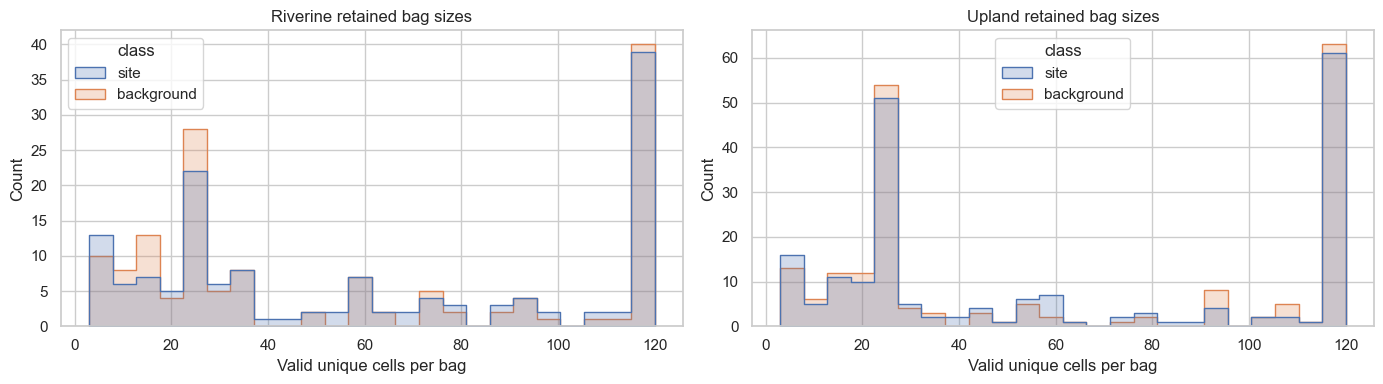

In [4]:
fig, axes = plt.subplots(1, len(prepared), figsize=(7 * len(prepared), 4), squeeze=False)
for ax, (setting_name, item) in zip(axes.ravel(), prepared.items()):
    dataset = item['dataset']
    sizes = pd.DataFrame({
        'cells': [bag.n_samples for bag in dataset.collections],
        'class': ['site' if bag.label == 1 else 'background' for bag in dataset.collections],
    })
    sns.histplot(data=sizes, x='cells', hue='class', bins=24, element='step', ax=ax)
    ax.set_title(f'{setting_name.title()} retained bag sizes')
    ax.set_xlabel('Valid unique cells per bag')
plt.tight_layout()

## 3. Repeated spatial grouped validation for M0–M3

Every method receives the same bags and immutable folds. Scaling and bandwidths are fitted inside each training fold. The raw fold table includes AUC, PR AUC, continuous Boyce index, top-5% lift, timing, memory diagnostics, and convergence status.

In [5]:
if REUSE_SAVED_CV and SAVED_RESULTS_PATH.exists():
    saved = json.loads(SAVED_RESULTS_PATH.read_text())
    cv_rows = [
        {'setting': setting_name, **row}
        for setting_name in SETTINGS_TO_RUN
        for row in saved['settings'][setting_name]['fold_results']
    ]
else:
    if REUSE_SAVED_CV:
        warnings.warn(f'Saved results not found at {SAVED_RESULTS_PATH}; refitting models.')
    cv_rows = []
    for setting_name in SETTINGS_TO_RUN:
        item = prepared[setting_name]
        rows = run_comparison(item['dataset'], item['fold_plan'], config)
        cv_rows.extend({'setting': setting_name, **row} for row in rows)

cv = pd.DataFrame(cv_rows)
assert len(cv) == len(SETTINGS_TO_RUN) * 4 * config['n_splits'] * config['n_repeats']
assert cv[['auc', 'pr_auc', 'boyce', 'top_5_percent_lift']].notna().all().all()
cv.head()

,setting,auc,boyce,diagnostics,fit_seconds,fold,method,n_test,n_train,peak_python_memory_mb,pr_auc,predict_seconds,repeat,top_5_percent_lift
0,riverine,0.735222,0.910844,"{'constructed_gram_matrix': True, 'converged':...",5.093770,1,M0,57,229,6.936876,0.721202,0.683443,1,1.965517
1,riverine,0.607143,0.329140,"{'constructed_gram_matrix': True, 'converged':...",2.692043,2,M0,57,229,5.249161,0.582124,0.743579,1,0.000000
2,riverine,0.894089,0.822473,"{'constructed_gram_matrix': True, 'converged':...",2.598760,3,M0,57,229,5.203118,0.852618,0.727972,1,1.357143
3,riverine,0.602217,0.305823,"{'constructed_gram_matrix': True, 'converged':...",2.696721,4,M0,57,229,5.163656,0.658924,0.648585,1,2.035714
4,riverine,0.601665,0.344656,"{'constructed_gram_matrix': True, 'converged':...",4.970732,5,M0,58,228,6.613454,0.592253,0.683061,1,1.333333


In [6]:
summary = (
    cv.groupby(['setting', 'method'])
      .agg(
          auc_mean=('auc', 'mean'), auc_sd=('auc', 'std'),
          pr_auc_mean=('pr_auc', 'mean'),
          boyce_mean=('boyce', 'mean'),
          top5_lift_mean=('top_5_percent_lift', 'mean'),
          median_fit_seconds=('fit_seconds', 'median'),
          median_predict_seconds=('predict_seconds', 'median'),
          median_peak_memory_mb=('peak_python_memory_mb', 'median'),
          converged=('diagnostics', lambda values: sum(bool(v['converged']) for v in values)),
      )
      .round(4)
)
display(summary)

auc_mean  auc_sd  pr_auc_mean  boyce_mean  top5_lift_mean  \
setting  method                                                              
riverine M0        0.6761  0.0902       0.6700      0.5727          1.2716   
         M1        0.6847  0.0857       0.6712      0.6600          1.2073   
         M2        0.6910  0.0930       0.6733      0.6065          1.2716   
         M3        0.6592  0.0821       0.6530      0.5059          1.2705   
upland   M0        0.7735  0.0392       0.7776      0.7978          1.9001   
         M1        0.7663  0.0409       0.7737      0.8083          1.9001   
         M2        0.7761  0.0383       0.7801      0.7933          1.9001   
         M3        0.7688  0.0392       0.7739      0.8475          1.9001   

                 median_fit_seconds  median_predict_seconds  \
setting  method                                               
riverine M0                  2.7013                  0.6833   
         M1                  0.2930                  0.0548   
         M2                  0.2639                  0.0588   
         M3                  1.3368                  1.2530   
upland   M0                  4.9174                  1.2211   
         M1                  0.3255                  0.0756   
         M2                  0.3378                  0.0825   
         M3                  1.7541                  1.5534   

                 median_peak_memory_mb  converged  
setting  method                                    
riverine M0                     5.1741         10  
         M1                     4.7159         10  
         M2                     4.7129         10  
         M3                     4.7847         10  
upland   M0                     6.3003         10  
         M1                     4.7886         10  
         M2                     4.7707         10  
         M3                     6.2558         10

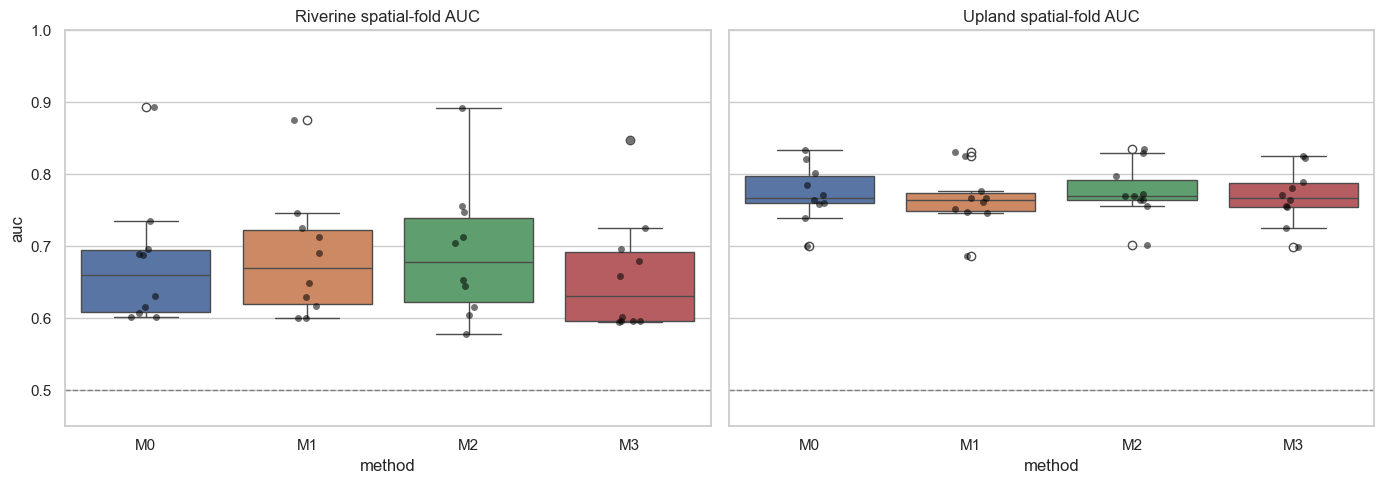

In [7]:
fig, axes = plt.subplots(1, len(SETTINGS_TO_RUN), figsize=(7 * len(SETTINGS_TO_RUN), 5), sharey=True)
axes = np.atleast_1d(axes)
for ax, setting_name in zip(axes, SETTINGS_TO_RUN):
    subset = cv[cv['setting'] == setting_name]
    sns.boxplot(data=subset, x='method', y='auc', hue='method', legend=False, ax=ax)
    sns.stripplot(data=subset, x='method', y='auc', color='black', alpha=0.55, ax=ax)
    ax.axhline(0.5, color='grey', linestyle='--', linewidth=1)
    ax.set_title(f'{setting_name.title()} spatial-fold AUC')
    ax.set_ylim(0.45, 1.0)
plt.tight_layout()

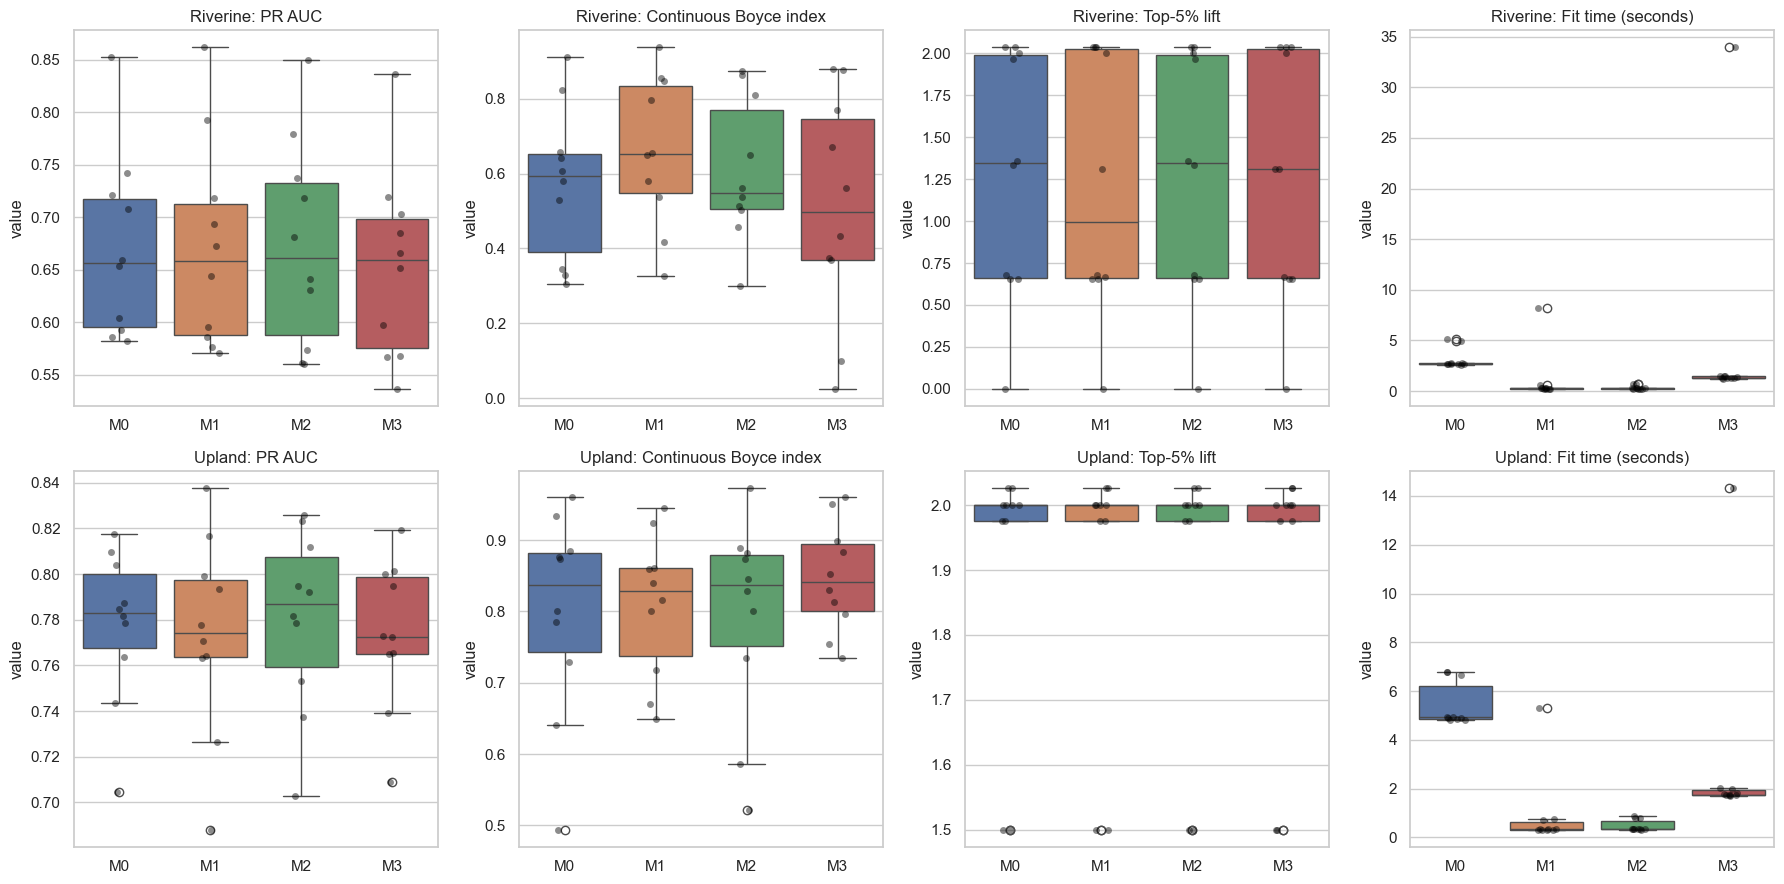

In [8]:
metric_labels = {
    'pr_auc': 'PR AUC',
    'boyce': 'Continuous Boyce index',
    'top_5_percent_lift': 'Top-5% lift',
    'fit_seconds': 'Fit time (seconds)',
}
long_metrics = cv.melt(
    id_vars=['setting', 'method', 'repeat', 'fold'],
    value_vars=list(metric_labels),
    var_name='metric', value_name='value',
)
fig, axes = plt.subplots(len(SETTINGS_TO_RUN), 4, figsize=(18, 4.5 * len(SETTINGS_TO_RUN)))
axes = np.asarray(axes).reshape(len(SETTINGS_TO_RUN), 4)
for row_index, setting_name in enumerate(SETTINGS_TO_RUN):
    for col_index, metric in enumerate(metric_labels):
        ax = axes[row_index, col_index]
        subset = long_metrics[(long_metrics.setting == setting_name) & (long_metrics.metric == metric)]
        sns.boxplot(data=subset, x='method', y='value', hue='method', legend=False, ax=ax)
        sns.stripplot(data=subset, x='method', y='value', color='black', alpha=0.45, ax=ax)
        ax.set_title(f'{setting_name.title()}: {metric_labels[metric]}')
        ax.set_xlabel('')
plt.tight_layout()

### Paired fold differences

Pairing is essential because each method was evaluated on the same fold. Intervals crossing zero do not support a method difference in this Section 6 run.

,setting,method,metric,n_pairs,mean_difference_vs_M0,standard_error,ci_95
0,riverine,M1,auc,10,0.0087,0.0078,"[-0.0066505200310213244, 0.02398532553467342]"
1,riverine,M1,pr_auc,10,0.0011,0.0069,"[-0.012423407975685283, 0.01472242988818961]"
2,riverine,M1,boyce,10,0.0873,0.0400,"[0.008801321793098768, 0.16576044057368616]"
3,riverine,M1,top_5_percent_lift,10,-0.0643,0.1199,"[-0.2992339615295939, 0.17058043115192564]"
4,riverine,M2,auc,10,0.0149,0.0086,"[-0.001974473703891956, 0.031828389110720536]"
5,riverine,M2,pr_auc,10,0.0032,0.0070,"[-0.01047981904660373, 0.01697006940746619]"
6,riverine,M2,boyce,10,0.0337,0.0394,"[-0.043525518110772675, 0.11102193861245674]"
7,riverine,M2,top_5_percent_lift,10,0.0000,0.0000,"[0.0, 0.0]"
8,riverine,M3,auc,10,-0.0168,0.0055,"[-0.027634854328928073, -0.005998575261695359]"
9,riverine,M3,pr_auc,10,-0.0170,0.0055,"[-0.02788997849958754, -0.006135110113334896]"


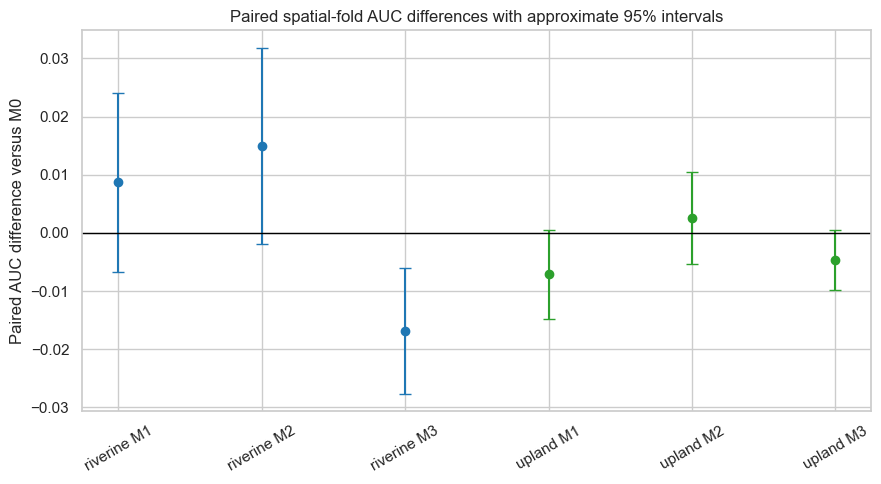

In [9]:
paired_rows = []
for setting_name in SETTINGS_TO_RUN:
    paired = paired_differences(cv[cv.setting == setting_name].drop(columns='setting').to_dict('records'))
    for method, metrics in paired.items():
        for metric, values in metrics.items():
            paired_rows.append({'setting': setting_name, 'method': method, 'metric': metric, **values})
paired_table = pd.DataFrame(paired_rows)
display(paired_table.round(4))

auc_pairs = paired_table[paired_table.metric == 'auc'].copy()
fig, ax = plt.subplots(figsize=(9, 5))
for index, row in auc_pairs.reset_index(drop=True).iterrows():
    color = {'riverine': 'tab:blue', 'upland': 'tab:green'}[row.setting]
    ax.errorbar(
        index, row.mean_difference_vs_M0,
        yerr=[[row.mean_difference_vs_M0 - row.ci_95[0]], [row.ci_95[1] - row.mean_difference_vs_M0]],
        fmt='o', color=color, capsize=4,
    )
ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(range(len(auc_pairs)), [f'{r.setting} {r.method}' for r in auc_pairs.itertuples()], rotation=30)
ax.set_ylabel('Paired AUC difference versus M0')
ax.set_title('Paired spatial-fold AUC differences with approximate 95% intervals')
plt.tight_layout()

## 4. Dedicated spatial train/test/holdout diagnostic

Repeated CV above is the primary comparison. For map inspection, this section reserves one spatial fold as a final holdout and a second fold as a test set; the remaining folds train each model. Nothing from test or holdout is used for scaling or bandwidth estimation.

In [10]:
def three_way_partition(dataset, plan, repeat=0, test_fold=0, holdout_fold=1):
    assignments = {a.fold: a for a in plan.assignments if a.repeat == repeat}
    test_indices = set(assignments[test_fold].test_indices)
    holdout_indices = set(assignments[holdout_fold].test_indices)
    assert not test_indices & holdout_indices
    train_indices = set(range(dataset.n_locations)) - test_indices - holdout_indices
    return (
        dataset.subset(sorted(train_indices)),
        dataset.subset(sorted(test_indices)),
        dataset.subset(sorted(holdout_indices)),
    )

partition_data = {}
partition_models = {}
partition_predictions = []

for setting_name, item in prepared.items():
    train, test, holdout = three_way_partition(
        item['dataset'], item['fold_plan'], PARTITION_REPEAT, TEST_FOLD, HOLDOUT_FOLD
    )
    partition_data[setting_name] = {'train': train, 'test': test, 'holdout': holdout}
    partition_models[setting_name] = {}
    for method, spec in model_specs(config).items():
        model = DistributionClassifier(
            spec, lambda_reg=config['lambda_reg'], seed=config['seed'], round_exact_kernel=True
        ).fit(train)
        partition_models[setting_name][method] = model
        for partition_name, partition in [('test', test), ('holdout', holdout)]:
            scores = np.asarray(model.predict_bags(partition))
            labels = np.asarray(partition.labels, dtype=int)
            partition_predictions.extend(
                {
                    'setting': setting_name, 'method': method, 'partition': partition_name,
                    'bag_id': bag.id, 'label': int(label), 'score': float(score),
                }
                for bag, label, score in zip(partition.collections, labels, scores)
            )

partition_scores = pd.DataFrame(partition_predictions)
partition_metric_rows = []
for keys, group in partition_scores.groupby(['setting', 'method', 'partition']):
    setting_name, method, partition_name = keys
    partition_metric_rows.append({
        'setting': setting_name, 'method': method, 'partition': partition_name,
        **fold_metrics(group.label.to_numpy(), group.score.to_numpy()),
    })
partition_metrics = pd.DataFrame(partition_metric_rows)
display(partition_metrics.round(4))

,setting,method,partition,auc,pr_auc,boyce,top_5_percent_lift
0,riverine,M0,holdout,0.5948,0.5633,0.3110,0.0000
1,riverine,M0,test,0.7155,0.7572,0.3253,1.9655
2,riverine,M1,holdout,0.6145,0.5812,0.3207,0.0000
3,riverine,M1,test,0.7081,0.7512,0.7731,1.9655
4,riverine,M2,holdout,0.5800,0.5548,0.4642,0.0000
5,riverine,M2,test,0.7278,0.7624,0.7500,1.9655
6,riverine,M3,holdout,0.5776,0.5403,0.3181,0.6552
7,riverine,M3,test,0.6798,0.7145,0.7201,1.9655
8,upland,M0,holdout,0.7506,0.7675,0.8622,1.5192
9,upland,M0,test,0.8026,0.7913,0.9451,1.9750


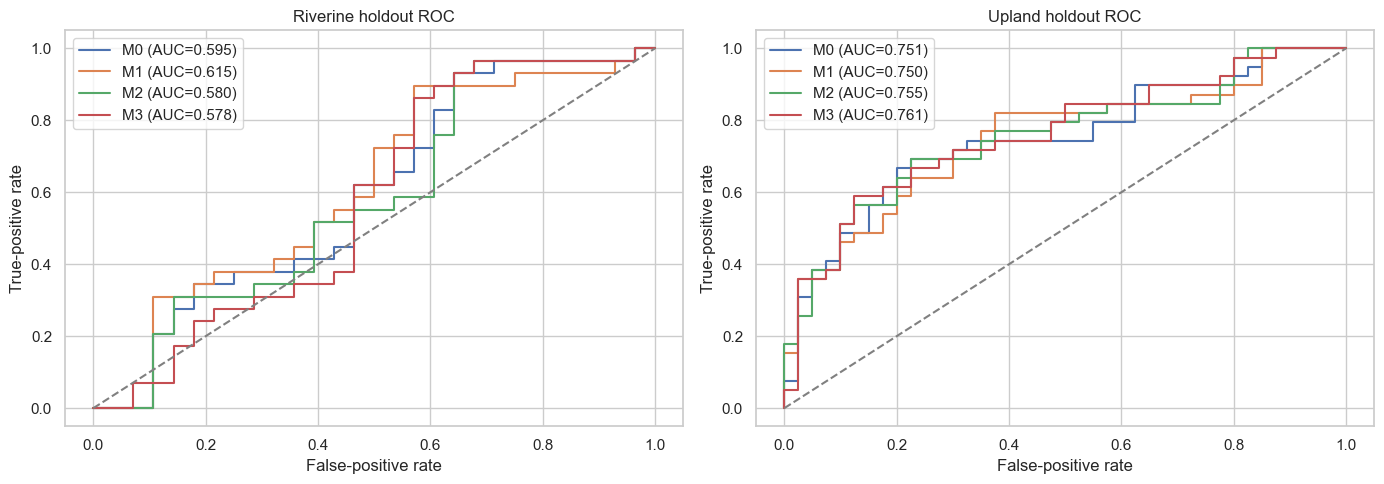

In [11]:
fig, axes = plt.subplots(1, len(SETTINGS_TO_RUN), figsize=(7 * len(SETTINGS_TO_RUN), 5))
axes = np.atleast_1d(axes)
for ax, setting_name in zip(axes, SETTINGS_TO_RUN):
    for method in ['M0', 'M1', 'M2', 'M3']:
        group = partition_scores[
            (partition_scores.setting == setting_name)
            & (partition_scores.method == method)
            & (partition_scores.partition == 'holdout')
        ]
        fpr, tpr, _ = roc_curve(group.label, group.score)
        auc_value = partition_metrics[
            (partition_metrics.setting == setting_name)
            & (partition_metrics.method == method)
            & (partition_metrics.partition == 'holdout')
        ].auc.iloc[0]
        ax.plot(fpr, tpr, label=f'{method} (AUC={auc_value:.3f})')
    ax.plot([0, 1], [0, 1], '--', color='grey')
    ax.set_title(f'{setting_name.title()} holdout ROC')
    ax.set_xlabel('False-positive rate')
    ax.set_ylabel('True-positive rate')
    ax.legend()
plt.tight_layout()

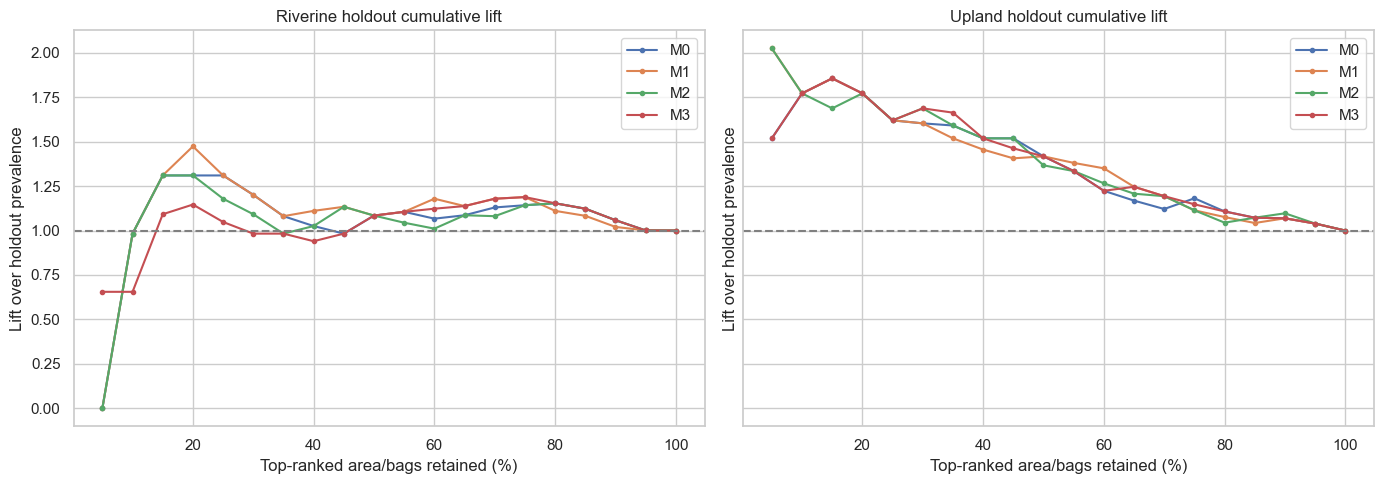

In [12]:
def cumulative_lift(labels, scores, fractions=np.linspace(0.05, 1.0, 20)):
    labels = np.asarray(labels)
    scores = np.asarray(scores)
    order = np.argsort(scores)[::-1]
    baseline = labels.mean()
    return pd.DataFrame({
        'fraction': fractions,
        'lift': [labels[order[:max(1, int(np.ceil(f * len(labels))))]].mean() / baseline for f in fractions],
    })

fig, axes = plt.subplots(1, len(SETTINGS_TO_RUN), figsize=(7 * len(SETTINGS_TO_RUN), 5), sharey=True)
axes = np.atleast_1d(axes)
for ax, setting_name in zip(axes, SETTINGS_TO_RUN):
    for method in ['M0', 'M1', 'M2', 'M3']:
        group = partition_scores[
            (partition_scores.setting == setting_name)
            & (partition_scores.method == method)
            & (partition_scores.partition == 'holdout')
        ]
        curve = cumulative_lift(group.label, group.score)
        ax.plot(curve.fraction * 100, curve.lift, marker='o', markersize=3, label=method)
    ax.axhline(1, color='grey', linestyle='--')
    ax.set_title(f'{setting_name.title()} holdout cumulative lift')
    ax.set_xlabel('Top-ranked area/bags retained (%)')
    ax.set_ylabel('Lift over holdout prevalence')
    ax.legend()
plt.tight_layout()

## 5. Lazy prediction maps with test and holdout sites

The map grid is built block-by-block from each setting's all-band raster mask. Each map anchor is represented by the distribution of valid cells in an explicit focal window—the `FO` in KLRfome. The core raster predictor traverses every cell (`stride=1`), producing overlapping windows. This notebook can subsample focal anchors with `MAP_STRIDE` for whole-area inspection; that is a map-preview approximation, not a change to the fitted representation. Models remain fitted only on the three-way training partition, and riverine and upland maps use their corresponding models. M3 prediction is batched to bound sliced-Wasserstein memory use.

### 5.1 Riverine map validation

In [13]:
def raster_source_for_setting(setting_name):
    setting = config['settings'][setting_name]
    csv_path = data_root / setting['csv']
    raster_directory = data_root / setting['raster_directory']
    columns = pd.read_csv(csv_path, nrows=0).columns
    excluded = {'Unnamed: 0', 'x', 'y', 'SITENO', 'presence'}
    feature_names = [column for column in columns if column not in excluded]
    paths = [str(raster_directory / f'{feature}.tif') for feature in feature_names]
    return RasterSource(paths, band_names=feature_names), feature_names

def _aligned_start(offset, stride):
    return ((int(offset) + stride - 1) // stride) * stride

def build_lazy_map_bags(source, feature_names, stride=24, window_size=7, block_size=512, min_cells=3):
    if window_size % 2 != 1:
        raise ValueError('window_size must be odd')
    radius = window_size // 2
    bags, centers = [], []
    for block in source.iter_windows(block_size=block_size):
        row0 = max(0, int(block.row_off) - radius)
        col0 = max(0, int(block.col_off) - radius)
        row1 = min(source.height, int(block.row_off + block.height) + radius)
        col1 = min(source.width, int(block.col_off + block.width) + radius)
        expanded = Window(col0, row0, col1 - col0, row1 - row0)
        stack, valid = source.read_window(expanded)
        rows = range(_aligned_start(block.row_off, stride), int(block.row_off + block.height), stride)
        cols = range(_aligned_start(block.col_off, stride), int(block.col_off + block.width), stride)
        for row in rows:
            for col in cols:
                local_row, local_col = row - row0, col - col0
                if not valid[local_row, local_col]:
                    continue
                r0, r1 = max(0, local_row - radius), min(valid.shape[0], local_row + radius + 1)
                c0, c1 = max(0, local_col - radius), min(valid.shape[1], local_col + radius + 1)
                local_valid = valid[r0:r1, c0:c1]
                window_valid = local_valid.ravel()
                samples = stack[:, r0:r1, c0:c1].reshape(len(feature_names), -1).T[window_valid]
                if len(samples) < min_cells:
                    continue
                valid_rows, valid_cols = np.nonzero(local_valid)
                cell_x, cell_y = xy(
                    source.transform, row0 + r0 + valid_rows, col0 + c0 + valid_cols,
                    offset='center',
                )
                coordinates = np.column_stack([cell_x, cell_y])
                bag_id = f'map-{row}-{col}'
                bags.append(Bag(samples, 0, bag_id, coordinates=coordinates))
                x_coord, y_coord = xy(source.transform, row, col, offset='center')
                centers.append({'bag_id': bag_id, 'row': row, 'col': col, 'x': x_coord, 'y': y_coord})
    return BagDataset(
        bags, feature_names, crs=source.crs, study_design='presence_background',
        metadata={'map_stride': stride, 'map_window': window_size},
    ), pd.DataFrame(centers)

def predict_map_batched(model, dataset, batch_size, description):
    """Predict ordered focal bags in bounded batches and return one score vector."""
    if batch_size is None:
        return np.asarray(model.predict_bags(dataset))
    score_blocks = []
    starts = range(0, dataset.n_locations, batch_size)
    for start in tqdm(starts, desc=description):
        stop = min(start + batch_size, dataset.n_locations)
        batch = dataset.subset(range(start, stop))
        score_blocks.append(np.asarray(model.predict_bags(batch)))
    return np.concatenate(score_blocks)

map_source, map_feature_names = raster_source_for_setting(MAP_SETTING)
map_bags, map_centers = build_lazy_map_bags(
    map_source, map_feature_names, MAP_STRIDE, MAP_WINDOW, MAP_BLOCK_SIZE, MAP_MIN_VALID_CELLS
)
print(f'Built {map_bags.n_locations:,} map bags at stride {MAP_STRIDE}.')

Built 1,656 map bags at stride 24.


In [14]:
map_scores = map_centers.copy()
for method in MAP_METHODS:
    started = time.perf_counter()
    batch_size = MAP_M3_BATCH_SIZE if method == 'M3' else None
    map_scores[method] = predict_map_batched(
        partition_models[MAP_SETTING][method], map_bags, batch_size,
        description=f'{MAP_SETTING} {method}',
    )
    print(f'{method}: mapped in {time.perf_counter() - started:.2f}s')
map_scores.describe()

M0: mapped in 7.06s
M1: mapped in 2.09s
M2: mapped in 1.31s


riverine M3: 100%|██████████| 26/26 [00:16<00:00,  1.62it/s]

M3: mapped in 16.13s


,row,col,x,y,M0,M1,M2,M3
count,1656.000000,1656.000000,1.656000e+03,1656.000000,1656.000000,1656.000000,1656.000000,1656.000000
mean,1770.159420,1857.579710,1.717996e+06,502501.115495,0.469921,0.471006,0.465694,0.454644
std,862.981258,745.316171,7.925877e+03,9177.157240,0.206474,0.216151,0.219936,0.206678
min,24.000000,0.000000,1.698242e+06,480234.694224,0.052208,0.028967,0.035935,0.044403
25%,1080.000000,1224.000000,1.711258e+06,496313.678120,0.307040,0.299602,0.284838,0.294108
50%,1752.000000,1920.000000,1.718659e+06,502694.227285,0.457093,0.464599,0.457154,0.433476
75%,2352.000000,2376.000000,1.723509e+06,509840.442350,0.628449,0.637211,0.631513,0.600127
max,3864.000000,3792.000000,1.738567e+06,521070.208881,0.945112,0.965801,0.951450,0.969499


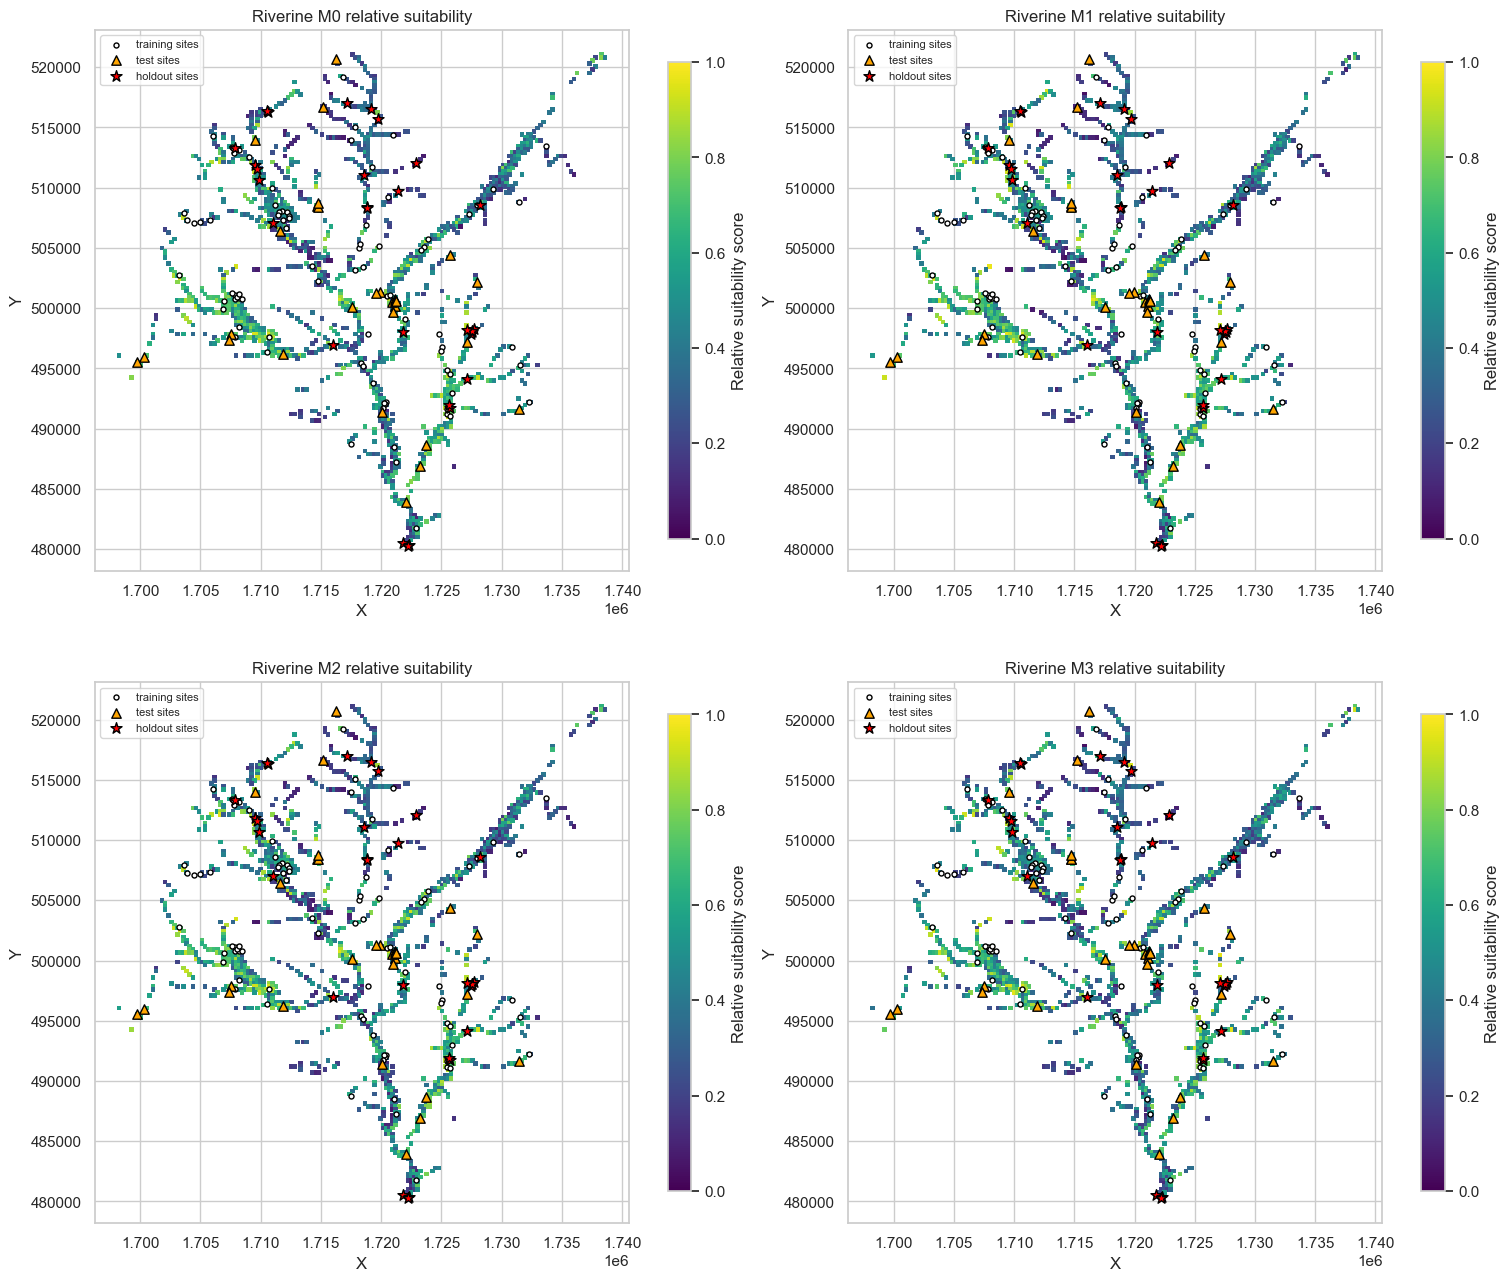

In [15]:
def site_centroids(dataset):
    rows = []
    for bag in dataset.collections:
        if bag.label != 1 or bag.coordinates is None:
            continue
        center = np.asarray(bag.coordinates).mean(axis=0)
        rows.append({'bag_id': bag.id, 'x': center[0], 'y': center[1]})
    return pd.DataFrame(rows)

training_sites = site_centroids(partition_data[MAP_SETTING]['train'])
test_sites = site_centroids(partition_data[MAP_SETTING]['test'])
holdout_sites = site_centroids(partition_data[MAP_SETTING]['holdout'])

fig, axes = plt.subplots(2, 2, figsize=(15, 13), constrained_layout=True)
for ax, method in zip(axes.ravel(), MAP_METHODS):
    image = ax.scatter(
        map_scores.x, map_scores.y, c=map_scores[method], s=11, marker='s',
        cmap='viridis', vmin=0, vmax=1, linewidths=0, rasterized=True,
    )
    ax.scatter(training_sites.x, training_sites.y, s=13, c='white', edgecolors='black', label='training sites')
    ax.scatter(test_sites.x, test_sites.y, s=46, marker='^', c='orange', edgecolors='black', label='test sites')
    ax.scatter(holdout_sites.x, holdout_sites.y, s=70, marker='*', c='red', edgecolors='black', label='holdout sites')
    ax.set_title(f'{MAP_SETTING.title()} {method} relative suitability')
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(loc='best', fontsize=8)
    fig.colorbar(image, ax=ax, shrink=0.8, label='Relative suitability score')
plt.show()

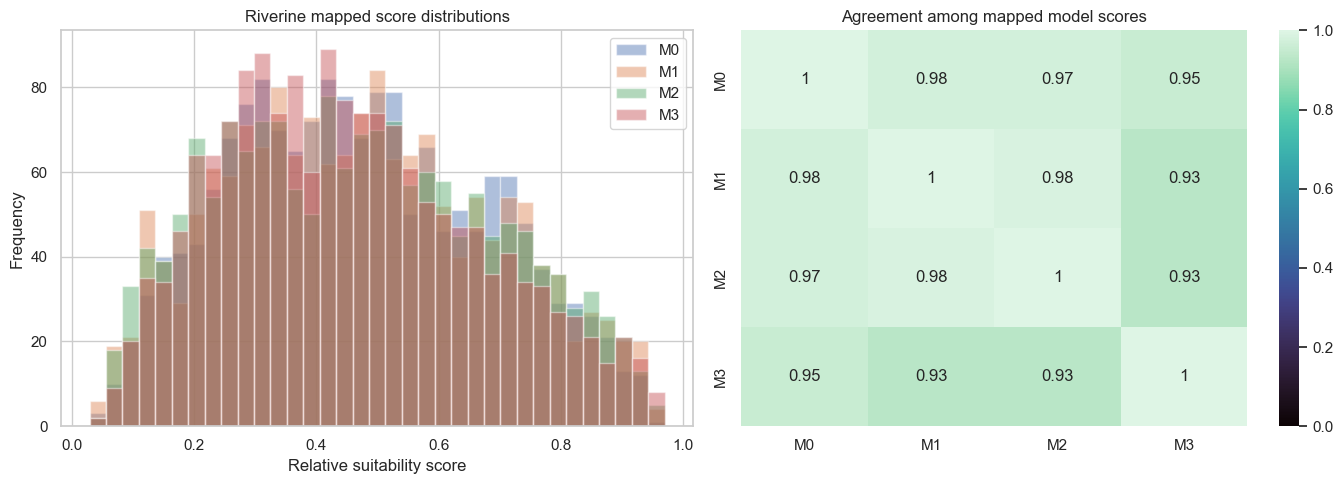

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
map_scores[MAP_METHODS].plot(kind='hist', bins=35, alpha=0.45, ax=axes[0])
axes[0].set_title(f'{MAP_SETTING.title()} mapped score distributions')
axes[0].set_xlabel('Relative suitability score')
sns.heatmap(map_scores[MAP_METHODS].corr(), annot=True, vmin=0, vmax=1, cmap='mako', ax=axes[1])
axes[1].set_title('Agreement among mapped model scores')
plt.tight_layout()

### 5.2 Upland map validation

This repeats the riverine map validation against the upland raster mask and upland models. It uses the same dedicated fold IDs for training, test, and holdout partitions, while keeping the two environmental settings fully separate.

In [17]:
UPLAND_MAP_SETTING = 'upland'
upland_map_source, upland_map_feature_names = raster_source_for_setting(UPLAND_MAP_SETTING)
upland_map_bags, upland_map_centers = build_lazy_map_bags(
    upland_map_source, upland_map_feature_names,
    MAP_STRIDE, MAP_WINDOW, MAP_BLOCK_SIZE, MAP_MIN_VALID_CELLS,
)
print(f'Built {upland_map_bags.n_locations:,} upland map bags at stride {MAP_STRIDE}.')

Built 11,463 upland map bags at stride 24.


In [18]:
upland_map_scores = upland_map_centers.copy()
for method in MAP_METHODS:
    started = time.perf_counter()
    batch_size = MAP_M3_BATCH_SIZE if method == 'M3' else None
    upland_map_scores[method] = predict_map_batched(
        partition_models[UPLAND_MAP_SETTING][method], upland_map_bags, batch_size,
        description=f'{UPLAND_MAP_SETTING} {method}',
    )
    print(f'{method}: mapped uplands in {time.perf_counter() - started:.2f}s')
upland_map_scores.describe()

M0: mapped uplands in 61.22s
M1: mapped uplands in 7.55s
M2: mapped uplands in 6.46s


upland M3: 100%|██████████| 180/180 [01:46<00:00,  1.70it/s]

M3: mapped uplands in 106.09s


,row,col,x,y,M0,M1,M2,M3
count,11463.000000,11463.000000,1.146300e+04,11463.000000,11463.000000,11463.000000,11463.000000,11463.000000
mean,1842.979325,2112.860508,1.719137e+06,502949.669117,0.375161,0.389388,0.379533,0.376447
std,864.638290,853.059101,9.071643e+03,9194.778533,0.211843,0.211523,0.209798,0.207971
min,24.000000,24.000000,1.696923e+06,480181.522981,0.023683,0.019275,0.028670,0.025190
25%,1176.000000,1536.000000,1.713002e+06,496260.506877,0.204455,0.218302,0.210639,0.209993
50%,1824.000000,2136.000000,1.719383e+06,503151.499976,0.341872,0.355719,0.346803,0.341617
75%,2472.000000,2760.000000,1.726018e+06,510042.493074,0.525003,0.539749,0.525436,0.526437
max,3984.000000,3984.000000,1.739035e+06,522293.147471,0.958546,0.977731,0.948107,0.950613


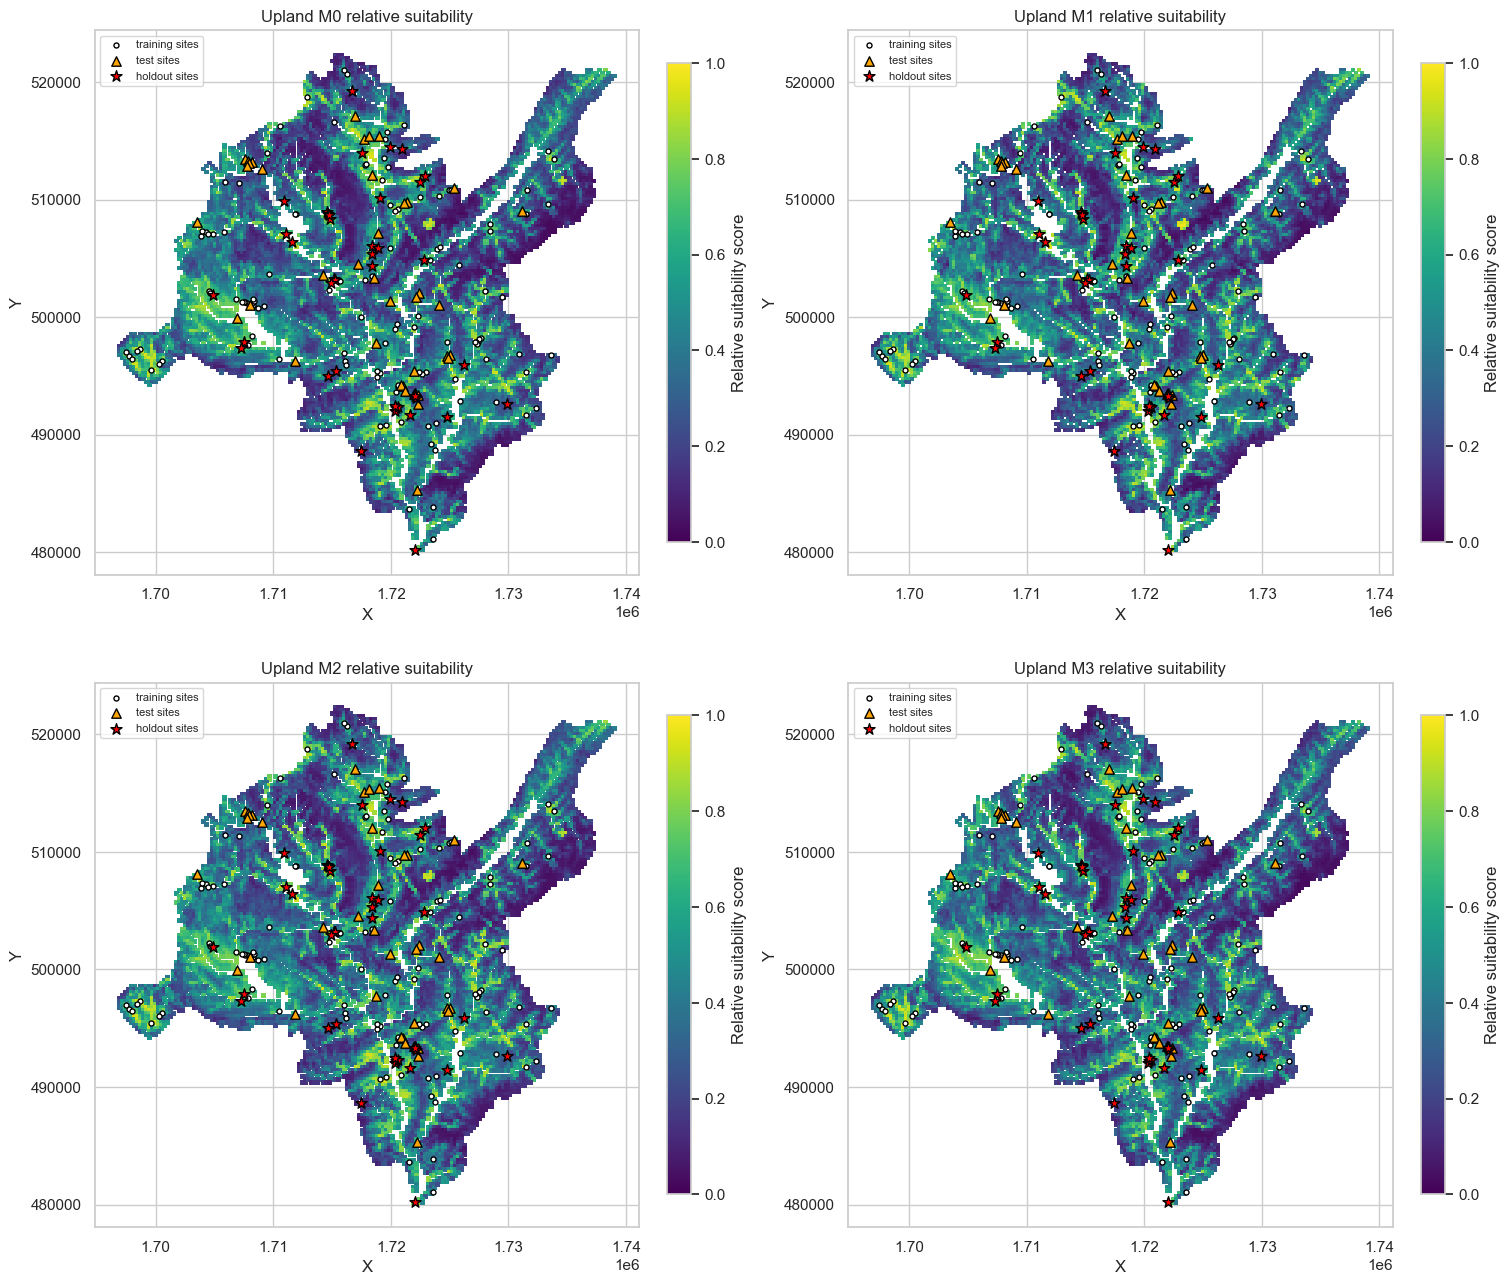

In [19]:
upland_training_sites = site_centroids(partition_data[UPLAND_MAP_SETTING]['train'])
upland_test_sites = site_centroids(partition_data[UPLAND_MAP_SETTING]['test'])
upland_holdout_sites = site_centroids(partition_data[UPLAND_MAP_SETTING]['holdout'])

fig, axes = plt.subplots(2, 2, figsize=(15, 13), constrained_layout=True)
for ax, method in zip(axes.ravel(), MAP_METHODS):
    image = ax.scatter(
        upland_map_scores.x, upland_map_scores.y, c=upland_map_scores[method],
        s=11, marker='s', cmap='viridis', vmin=0, vmax=1,
        linewidths=0, rasterized=True,
    )
    ax.scatter(
        upland_training_sites.x, upland_training_sites.y, s=13,
        c='white', edgecolors='black', label='training sites',
    )
    ax.scatter(
        upland_test_sites.x, upland_test_sites.y, s=46, marker='^',
        c='orange', edgecolors='black', label='test sites',
    )
    ax.scatter(
        upland_holdout_sites.x, upland_holdout_sites.y, s=70, marker='*',
        c='red', edgecolors='black', label='holdout sites',
    )
    ax.set_title(f'Upland {method} relative suitability')
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(loc='best', fontsize=8)
    fig.colorbar(image, ax=ax, shrink=0.8, label='Relative suitability score')
plt.show()

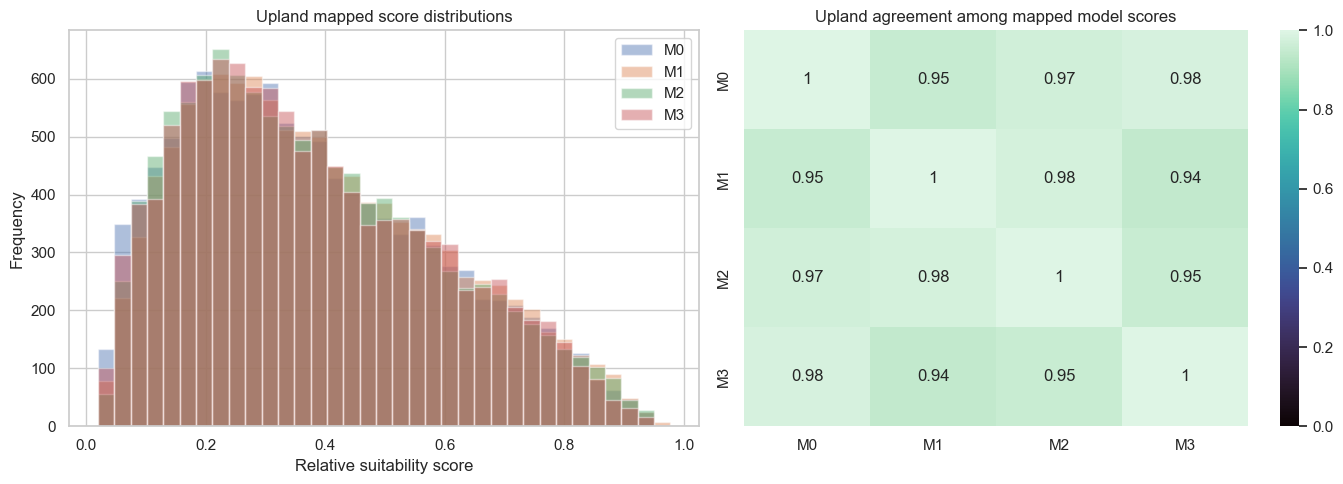

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
upland_map_scores[MAP_METHODS].plot(kind='hist', bins=35, alpha=0.45, ax=axes[0])
axes[0].set_title('Upland mapped score distributions')
axes[0].set_xlabel('Relative suitability score')
sns.heatmap(
    upland_map_scores[MAP_METHODS].corr(), annot=True, vmin=0, vmax=1,
    cmap='mako', ax=axes[1],
)
axes[1].set_title('Upland agreement among mapped model scores')
plt.tight_layout()

## 6. Classical baselines on the same bags and spatial folds

These baselines deliberately summarize each bag to one feature-mean vector. Logistic regression tests a simple linear environmental response; random forest tests a flexible nonlinear response without distribution regression. The optional mean-plus-standard-deviation and geometry-only models are diagnostics, not candidate replacements. In particular, a strong geometry-only score indicates that site and background support differ in a learnable way.

In [21]:
from benchmarks.run_section6_sensitivity import run_baseline_comparison  # noqa: E402

baseline_rows = []
for setting_name in SETTINGS_TO_RUN:
    item = prepared[setting_name]
    rows = run_baseline_comparison(
        item['dataset'], item['fold_plan'], seed=config['seed'], include_diagnostics=True,
    )
    baseline_rows.extend({'setting': setting_name, **row} for row in rows)

baseline_cv = pd.DataFrame(baseline_rows)
baseline_summary = (
    baseline_cv.groupby(['setting', 'method'])
      .agg(
          auc_mean=('auc', 'mean'), auc_sd=('auc', 'std'),
          pr_auc_mean=('pr_auc', 'mean'),
          boyce_mean=('boyce', 'mean'),
          top5_lift_mean=('top_5_percent_lift', 'mean'),
          median_fit_seconds=('fit_seconds', 'median'),
          median_predict_seconds=('predict_seconds', 'median'),
          median_peak_memory_mb=('peak_python_memory_mb', 'median'),
      )
      .round(4)
)
display(baseline_summary)

auc_mean  auc_sd  pr_auc_mean  boyce_mean  \
setting  method                                                    
riverine LR-mean         0.6219  0.0691       0.6214      0.4515   
         LR-mean-std     0.6400  0.0773       0.6632      0.5049   
         NEG-geometry    0.7688  0.0270       0.8016      0.4934   
         RF-mean         0.6918  0.0831       0.7016      0.5967   
upland   LR-mean         0.7423  0.0535       0.7430      0.8181   
         LR-mean-std     0.7636  0.0309       0.7650      0.8508   
         NEG-geometry    0.7979  0.0433       0.8190      0.6853   
         RF-mean         0.7617  0.0536       0.7741      0.8488   

                       top5_lift_mean  median_fit_seconds  \
setting  method                                             
riverine LR-mean               1.0704              0.0252   
         LR-mean-std           1.5349              0.0497   
         NEG-geometry          1.9338              0.0358   
         RF-mean               1.7349              5.1332   
upland   LR-mean               1.7001              0.0325   
         LR-mean-std           1.7501              0.0610   
         NEG-geometry          2.0001              0.0438   
         RF-mean               1.8508              5.2273   

                       median_predict_seconds  median_peak_memory_mb  
setting  method                                                       
riverine LR-mean                       0.0033                 0.1335  
         LR-mean-std                   0.0083                 0.2404  
         NEG-geometry                  0.0066                 0.1108  
         RF-mean                       0.1245                 1.6092  
upland   LR-mean                       0.0038                 0.1575  
         LR-mean-std                   0.0104                 0.2727  
         NEG-geometry                  0.0086                 0.1388  
         RF-mean                       0.1264                 1.9573

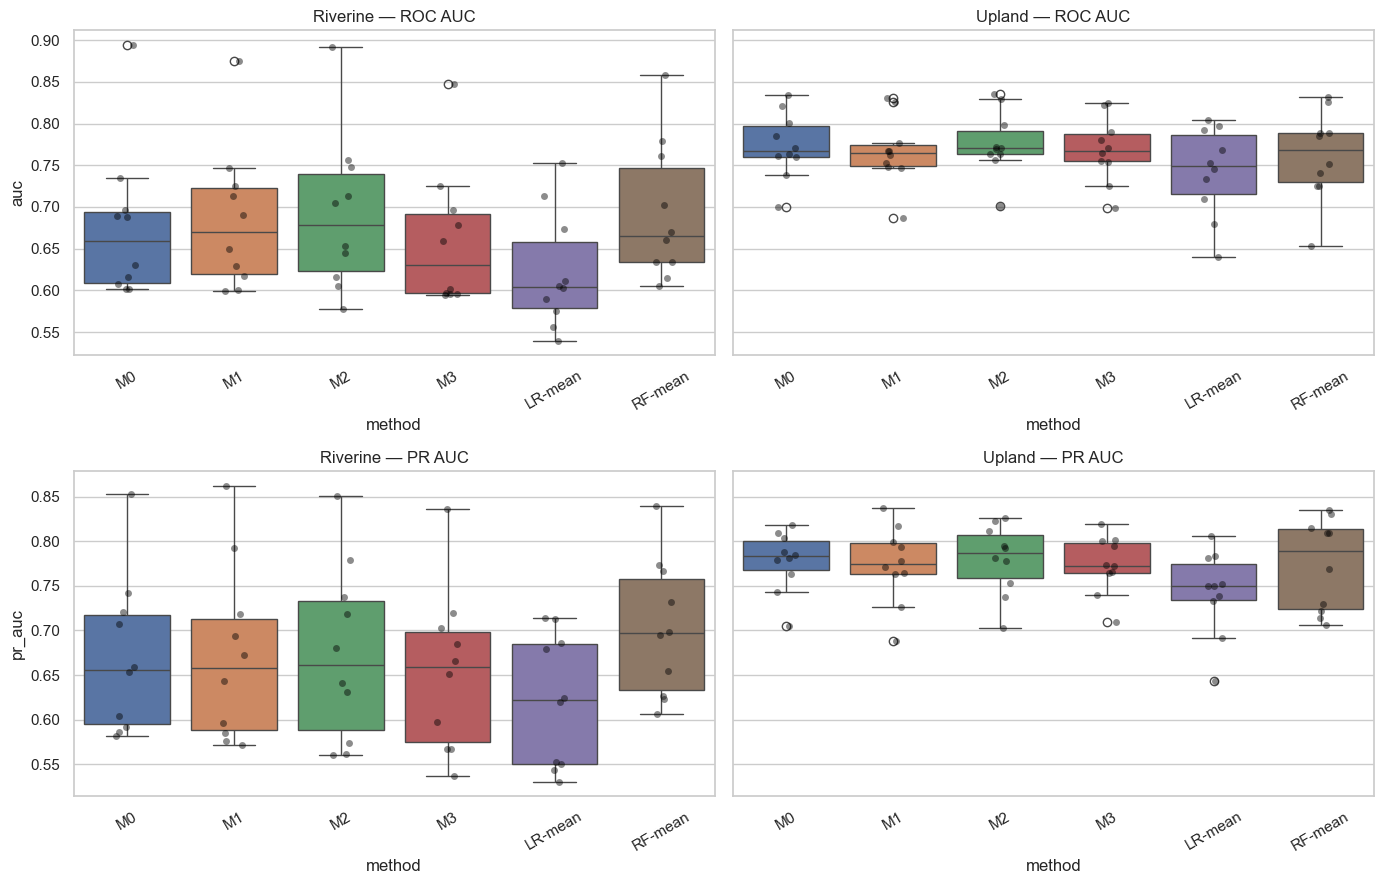

In [22]:
candidate_baselines = baseline_cv[baseline_cv['method'].isin(['LR-mean', 'RF-mean'])]
comparison_cv = pd.concat(
    [cv, candidate_baselines], ignore_index=True, sort=False,
)
fig, axes = plt.subplots(2, len(SETTINGS_TO_RUN), figsize=(7 * len(SETTINGS_TO_RUN), 9), sharey='row')
for column, setting_name in enumerate(SETTINGS_TO_RUN):
    subset = comparison_cv[comparison_cv['setting'] == setting_name]
    for row, (metric, label) in enumerate([('auc', 'ROC AUC'), ('pr_auc', 'PR AUC')]):
        sns.boxplot(data=subset, x='method', y=metric, hue='method', legend=False, ax=axes[row, column])
        sns.stripplot(data=subset, x='method', y=metric, color='black', alpha=0.45, ax=axes[row, column])
        axes[row, column].set_title(f'{setting_name.title()} — {label}')
        axes[row, column].tick_params(axis='x', rotation=30)
plt.tight_layout()

## 7. Riverine support sensitivity

The tracked sensitivity runner compares the original bags, an exact permutation of site bag sample counts onto backgrounds, and 7×7, 9×9, and 11×11 common focal windows for both classes. All focal designs share bag IDs, background anchors, and one spatial fold plan. Run `python benchmarks/run_section6_sensitivity.py` to regenerate the ignored result file.

In [23]:
SENSITIVITY_RESULTS_PATH = (
    REPO_ROOT / 'site_data/r91_section_6_data/section6_sensitivity/results.json'
)
if not SENSITIVITY_RESULTS_PATH.exists():
    warnings.warn(
        f'Sensitivity results not found at {SENSITIVITY_RESULTS_PATH}. Run the tracked runner first.'
    )
    sensitivity_cv = pd.DataFrame()
else:
    sensitivity_payload = json.loads(SENSITIVITY_RESULTS_PATH.read_text())
    sensitivity_rows = []
    for design, result in sensitivity_payload['designs'].items():
        for family in ('model_results', 'baseline_results'):
            sensitivity_rows.extend(
                {'design': design, 'family': family, **row}
                for row in result[family]
            )
    sensitivity_cv = pd.DataFrame(sensitivity_rows)

if not sensitivity_cv.empty:
    sensitivity_summary = (
        sensitivity_cv.groupby(['design', 'method'])
          .agg(
              auc_mean=('auc', 'mean'), auc_se=('auc', lambda x: x.std() / np.sqrt(x.count())),
              pr_auc_mean=('pr_auc', 'mean'),
              boyce_mean=('boyce', 'mean'),
              top5_lift_mean=('top_5_percent_lift', 'mean'),
          )
          .round(4)
    )
    display(sensitivity_summary)

auc_mean  auc_se  pr_auc_mean  \
design                 method                                        
exact_background_sizes LR-mean         0.6168  0.0223       0.6264   
                       LR-mean-std     0.6565  0.0242       0.6820   
                       M0              0.6835  0.0281       0.6804   
                       M1              0.6910  0.0281       0.6871   
                       M2              0.6941  0.0287       0.6846   
                       M3              0.6725  0.0258       0.6613   
                       NEG-geometry    0.7956  0.0109       0.8225   
                       RF-mean         0.6994  0.0252       0.7119   
focal_11               LR-mean         0.5995  0.0121       0.6018   
                       LR-mean-std     0.5588  0.0158       0.5770   
                       M0              0.6556  0.0159       0.6626   
                       M1              0.6546  0.0145       0.6532   
                       M2              0.6641  0.0141       0.6579   
                       M3              0.6453  0.0140       0.6516   
                       NEG-geometry    0.5529  0.0214       0.5981   
                       RF-mean         0.6749  0.0232       0.6796   
focal_7                LR-mean         0.6099  0.0125       0.6106   
                       LR-mean-std     0.5809  0.0177       0.5926   
                       M0              0.6649  0.0155       0.6712   
                       M1              0.6637  0.0160       0.6609   
                       M2              0.6699  0.0156       0.6627   
                       M3              0.6617  0.0158       0.6667   
                       NEG-geometry    0.5499  0.0172       0.5938   
                       RF-mean         0.6767  0.0296       0.6901   
focal_9                LR-mean         0.6018  0.0114       0.6039   
                       LR-mean-std     0.5715  0.0174       0.5919   
                       M0              0.6606  0.0160       0.6663   
                       M1              0.6586  0.0159       0.6578   
                       M2              0.6674  0.0157       0.6576   
                       M3              0.6570  0.0168       0.6628   
                       NEG-geometry    0.5297  0.0239       0.5778   
                       RF-mean         0.6820  0.0264       0.6907   
original               LR-mean         0.6219  0.0219       0.6214   
                       LR-mean-std     0.6400  0.0245       0.6632   
                       M0              0.6761  0.0285       0.6700   
                       M1              0.6847  0.0271       0.6712   
                       M2              0.6910  0.0294       0.6733   
                       M3              0.6592  0.0260       0.6530   
                       NEG-geometry    0.7688  0.0085       0.8016   
                       RF-mean         0.6918  0.0263       0.7016   

                                     boyce_mean  top5_lift_mean  
design                 method                                    
exact_background_sizes LR-mean           0.4563          1.2693  
                       LR-mean-std       0.5400          1.7337  
                       M0                0.6319          1.4050  
                       M1                0.5538          1.4729  
                       M2                0.6305          1.4050  
                       M3                0.6161          1.3348  
                       NEG-geometry      0.7553          2.0005  
                       RF-mean           0.6451          1.8039  
focal_11               LR-mean           0.3819          1.1333  
                       LR-mean-std       0.2404          1.3333  
                       M0                0.5535          1.3333  
                       M1                0.5572          1.2000  
                       M2                0.5704          1.2667  
                       M3                0.5079          1.4000  
                       NEG-geometry     

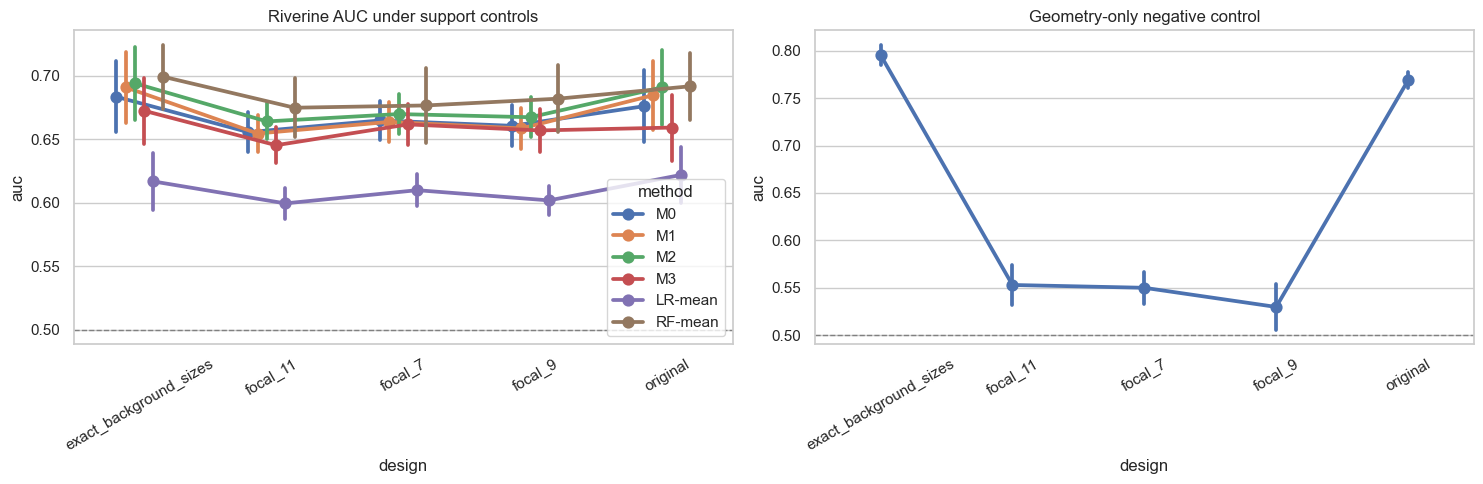

In [24]:
if not sensitivity_cv.empty:
    method_order = ['M0', 'M1', 'M2', 'M3', 'LR-mean', 'RF-mean']
    substantive = sensitivity_cv[sensitivity_cv['method'].isin(method_order)].copy()
    geometry = sensitivity_cv[sensitivity_cv['method'] == 'NEG-geometry'].copy()
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.pointplot(
        data=substantive, x='design', y='auc', hue='method', hue_order=method_order,
        errorbar=('se', 1), dodge=0.35, ax=axes[0],
    )
    axes[0].axhline(0.5, color='grey', linestyle='--', linewidth=1)
    axes[0].set_title('Riverine AUC under support controls')
    axes[0].tick_params(axis='x', rotation=30)
    sns.pointplot(data=geometry, x='design', y='auc', errorbar=('se', 1), ax=axes[1])
    axes[1].axhline(0.5, color='grey', linestyle='--', linewidth=1)
    axes[1].set_title('Geometry-only negative control')
    axes[1].tick_params(axis='x', rotation=30)
    plt.tight_layout()

## 8. Experimental ORF and spatial-shrinkage sensitivity

This section is deliberately separate from the canonical M0–M3 comparison. It evaluates orthogonal random features across three feature-map seeds, nominal finite-bag shrinkage, and coordinate-aware shrinkage at correlation ranges equal to 1, 3, and 7 raster cells. Those scales represent one-cell dependence, approximately the focal-window radius, and the full focal-window width. The true empirical correlation range is unknown, so this is a sensitivity analysis—not tuning and not a new default. Every variant uses the existing bags and immutable spatial folds.

In [25]:
extension_range_rows = []
extension_range_units = {}
for setting_name in SETTINGS_TO_RUN:
    source, _ = raster_source_for_setting(setting_name)
    cell_size = float(max(source.resolution))
    extension_range_units[setting_name] = {
        multiplier: multiplier * cell_size
        for multiplier in SPATIAL_RANGE_CELL_MULTIPLIERS
    }
    for multiplier, coordinate_range in extension_range_units[setting_name].items():
        extension_range_rows.append({
            'setting': setting_name,
            'raster_cell_size': cell_size,
            'range_cells': multiplier,
            'range_coordinate_units': coordinate_range,
            'crs': source.crs,
        })
extension_range_table = pd.DataFrame(extension_range_rows)
display(extension_range_table.round(3))

ess_rows = []
for setting_name, item in prepared.items():
    for bag in item['dataset'].collections:
        if bag.coordinates is None:
            raise ValueError(f'Bag {bag.id!r} lacks coordinates for spatial ESS')
        coordinates = np.asarray(bag.coordinates)
        unique_count = spatial_effective_sample_size(coordinates, 0.0)
        for multiplier in [0.0, *SPATIAL_RANGE_CELL_MULTIPLIERS]:
            coordinate_range = (
                0.0 if multiplier == 0 else extension_range_units[setting_name][multiplier]
            )
            effective_size = spatial_effective_sample_size(coordinates, coordinate_range)
            ess_rows.append({
                'setting': setting_name,
                'bag_id': bag.id,
                'class': 'site' if bag.label == 1 else 'background',
                'range_cells': multiplier,
                'range_label': 'independent' if multiplier == 0 else f'{multiplier:g} cells',
                'unique_cells': unique_count,
                'effective_size': effective_size,
                'effective_fraction': effective_size / unique_count,
            })
ess = pd.DataFrame(ess_rows)
ess_summary = (
    ess.groupby(['setting', 'class', 'range_label'], sort=False)
    .agg(
        bags=('bag_id', 'nunique'),
        median_unique_cells=('unique_cells', 'median'),
        median_effective_size=('effective_size', 'median'),
        median_effective_fraction=('effective_fraction', 'median'),
    )
    .round(3)
)
display(ess_summary)

,setting,raster_cell_size,range_cells,range_coordinate_units,crs
0,riverine,10.634,1.0,10.634,ESRI:102003
1,riverine,10.634,3.0,31.903,ESRI:102003
2,riverine,10.634,7.0,74.440,ESRI:102003
3,upland,10.634,1.0,10.634,ESRI:102003
4,upland,10.634,3.0,31.903,ESRI:102003
5,upland,10.634,7.0,74.440,ESRI:102003


bags  median_unique_cells  \
setting  class      range_label                              
riverine site       independent   143                 53.0   
                    1 cells       143                 53.0   
                    3 cells       143                 53.0   
                    7 cells       143                 53.0   
         background independent   143                 34.0   
                    1 cells       143                 34.0   
                    3 cells       143                 34.0   
                    7 cells       143                 34.0   
upland   site       independent   198                 35.5   
                    1 cells       198                 35.5   
                    3 cells       198                 35.5   
                    7 cells       198                 35.5   
         background independent   198                 28.0   
                    1 cells       198                 28.0   
                    3 cells       198                 28.0   
                    7 cells       198                 28.0   

                                 median_effective_size  \
setting  class      range_label                          
riverine site       independent                 53.000   
                    1 cells                     12.153   
                    3 cells                      3.078   
                    7 cells                      1.696   
         background independent                 34.000   
                    1 cells                      8.058   
                    3 cells                      2.424   
                    7 cells                      1.501   
upland   site       independent                 35.500   
                    1 cells                      8.404   
                    3 cells                      2.645   
                    7 cells                      1.581   
         background independent                 28.000   
                    1 cells                      7.004   
                    3 cells                      2.252   
                    7 cells                      1.448   

                                 median_effective_fraction  
setting  class      range_label                             
riverine site       independent                      1.000  
                    1 cells                          0.255  
                    3 cells                          0.076  
                    7 cells                          0.045  
         background independent                      1.000  
                    1 cells                          0.237  
                    3 cells                          0.071  
                    7 cells                          0.044  
upland   site       independent                      1.000  
                    1 cells                          0.254  
                    3 cells                          0.082  
                    7 cells                          0.052  
         background independent                      1.000  
                    1 cells                          0.250  
                    3 cells                          0.080  
                    7 cells                          0.052

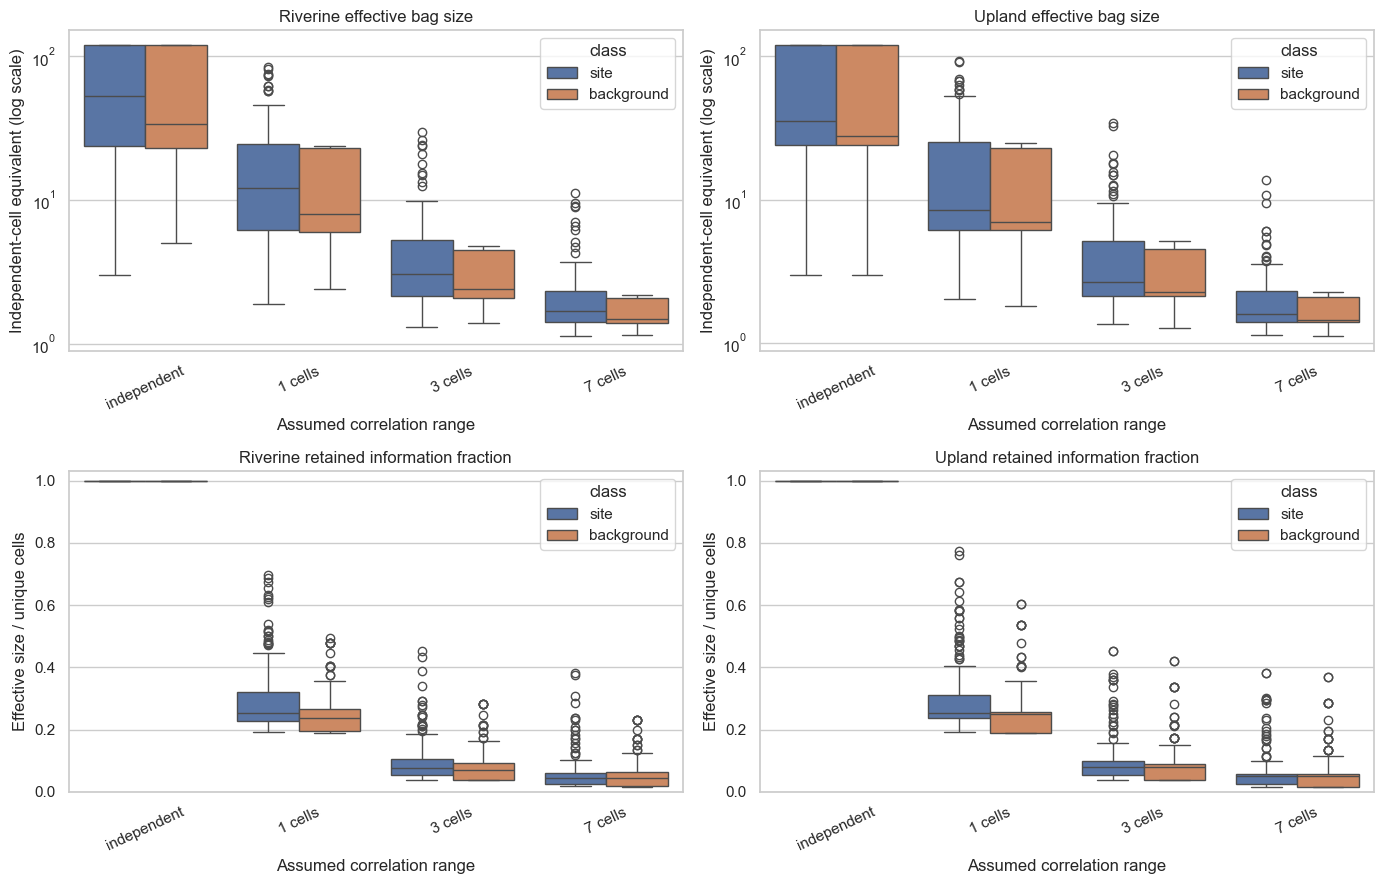

In [26]:
range_order = ['independent', *[f'{value:g} cells' for value in SPATIAL_RANGE_CELL_MULTIPLIERS]]
fig, axes = plt.subplots(2, len(SETTINGS_TO_RUN), figsize=(7 * len(SETTINGS_TO_RUN), 9))
axes = np.asarray(axes).reshape(2, len(SETTINGS_TO_RUN))
for column, setting_name in enumerate(SETTINGS_TO_RUN):
    subset = ess[ess.setting == setting_name]
    sns.boxplot(
        data=subset, x='range_label', y='effective_size', hue='class',
        order=range_order, ax=axes[0, column],
    )
    axes[0, column].set_yscale('log')
    axes[0, column].set_title(f'{setting_name.title()} effective bag size')
    axes[0, column].set_xlabel('Assumed correlation range')
    axes[0, column].set_ylabel('Independent-cell equivalent (log scale)')
    sns.boxplot(
        data=subset, x='range_label', y='effective_fraction', hue='class',
        order=range_order, ax=axes[1, column],
    )
    axes[1, column].set_ylim(0, 1.03)
    axes[1, column].set_title(f'{setting_name.title()} retained information fraction')
    axes[1, column].set_xlabel('Assumed correlation range')
    axes[1, column].set_ylabel('Effective size / unique cells')
    for ax in axes[:, column]:
        ax.tick_params(axis='x', rotation=25)
plt.tight_layout()

In [27]:
def extension_specs(setting_name):
    specifications = {
        'M1-ORF-empirical': (
            ModelSpec.m1(config['rff_features'], rff_scheme='orthogonal'), np.nan,
        ),
        'M1-ORF-shrink-nominal': (
            ModelSpec.m1(
                config['rff_features'], rff_scheme='orthogonal',
                embedding_estimator='shrinkage',
            ),
            0.0,
        ),
    }
    for multiplier, coordinate_range in extension_range_units[setting_name].items():
        specifications[f'M1-ORF-shrink-spatial-{multiplier:g}cell'] = (
            ModelSpec.m1(
                config['rff_features'], rff_scheme='orthogonal',
                embedding_estimator='shrinkage',
                shrinkage_effective_size='spatial',
                shrinkage_spatial_range=coordinate_range,
            ),
            multiplier,
        )
    return specifications

def run_extension_comparison(setting_name, dataset, plan):
    rows, prediction_rows = [], []
    specifications = extension_specs(setting_name)
    for seed in EXTENSION_RFF_SEEDS:
        for method, (spec, range_cells) in specifications.items():
            for assignment in plan.assignments:
                train = dataset.subset(assignment.train_indices)
                test = dataset.subset(assignment.test_indices)
                model = DistributionClassifier(
                    spec, lambda_reg=config['lambda_reg'], seed=seed, round_exact_kernel=True,
                )
                tracemalloc.start()
                fit_started = time.perf_counter()
                model.fit(train)
                fit_seconds = time.perf_counter() - fit_started
                predict_started = time.perf_counter()
                scores = np.asarray(model.predict_bags(test))
                predict_seconds = time.perf_counter() - predict_started
                _, peak_bytes = tracemalloc.get_traced_memory()
                tracemalloc.stop()
                if not np.isfinite(scores).all():
                    raise RuntimeError(
                        f'{setting_name} {method} seed {seed} produced nonfinite scores'
                    )
                labels = np.asarray(test.labels, dtype=int)
                diagnostics = model.diagnostics_
                rows.append({
                    'setting': setting_name, 'method': method, 'seed': seed,
                    'range_cells': range_cells,
                    'repeat': assignment.repeat + 1, 'fold': assignment.fold + 1,
                    'n_train': train.n_locations, 'n_test': test.n_locations,
                    **fold_metrics(labels, scores),
                    'fit_seconds': fit_seconds, 'predict_seconds': predict_seconds,
                    'peak_python_memory_mb': peak_bytes / (1024 ** 2),
                    'converged': bool(diagnostics['converged']),
                    'mean_effective_sample_size': diagnostics.get('mean_effective_sample_size'),
                    'mean_shrinkage_factor': diagnostics.get('mean_shrinkage_factor'),
                    'rff_frequency_cache_hit': diagnostics.get('rff_frequency_cache_hit'),
                })
                prediction_rows.extend({
                    'setting': setting_name, 'method': method, 'seed': seed,
                    'range_cells': range_cells,
                    'repeat': assignment.repeat + 1, 'fold': assignment.fold + 1,
                    'bag_id': bag.id, 'label': int(label), 'score': float(score),
                } for bag, label, score in zip(test.collections, labels, scores))
                print(
                    f'{setting_name} {method} seed={seed} repeat={assignment.repeat + 1} '
                    f'fold={assignment.fold + 1} fit={fit_seconds:.2f}s'
                )
    return rows, prediction_rows

if REUSE_SAVED_EXTENSION_CV and EXTENSION_RESULTS_PATH.exists():
    extension_payload = json.loads(EXTENSION_RESULTS_PATH.read_text())
elif RUN_EXTENSION_CV:
    extension_rows, extension_prediction_rows = [], []
    for setting_name in SETTINGS_TO_RUN:
        item = prepared[setting_name]
        setting_rows, setting_predictions = run_extension_comparison(
            setting_name, item['dataset'], item['fold_plan'],
        )
        extension_rows.extend(setting_rows)
        extension_prediction_rows.extend(setting_predictions)
    extension_payload = {
        'rff_seeds': EXTENSION_RFF_SEEDS,
        'spatial_range_cell_multipliers': SPATIAL_RANGE_CELL_MULTIPLIERS,
        'range_table': extension_range_rows,
        'fold_results': extension_rows,
        'predictions': extension_prediction_rows,
    }
    EXTENSION_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    write_strict_json(EXTENSION_RESULTS_PATH, extension_payload)
    print(f'Wrote {EXTENSION_RESULTS_PATH}')
elif EXTENSION_RESULTS_PATH.exists():
    extension_payload = json.loads(EXTENSION_RESULTS_PATH.read_text())
else:
    warnings.warn('Extension CV is disabled and no saved result exists.')
    extension_payload = {'fold_results': [], 'predictions': []}

extension_cv = pd.DataFrame(extension_payload['fold_results'])
extension_predictions = pd.DataFrame(extension_payload['predictions'])
if not extension_cv.empty:
    expected_rows = sum(
        len(prepared[setting]['fold_plan'].assignments)
        * len(EXTENSION_RFF_SEEDS)
        * (2 + len(SPATIAL_RANGE_CELL_MULTIPLIERS))
        for setting in SETTINGS_TO_RUN
    )
    assert len(extension_cv) == expected_rows
    assert extension_cv[['auc', 'pr_auc', 'fit_seconds', 'predict_seconds']].notna().all().all()
extension_cv.head()

riverine M1-ORF-empirical seed=42 repeat=1 fold=1 fit=2.65s
riverine M1-ORF-empirical seed=42 repeat=1 fold=2 fit=0.41s
riverine M1-ORF-empirical seed=42 repeat=1 fold=3 fit=0.39s
riverine M1-ORF-empirical seed=42 repeat=1 fold=4 fit=0.38s
riverine M1-ORF-empirical seed=42 repeat=1 fold=5 fit=1.63s
riverine M1-ORF-empirical seed=42 repeat=2 fold=1 fit=0.39s
riverine M1-ORF-empirical seed=42 repeat=2 fold=2 fit=0.39s
riverine M1-ORF-empirical seed=42 repeat=2 fold=3 fit=0.39s
riverine M1-ORF-empirical seed=42 repeat=2 fold=4 fit=0.38s
riverine M1-ORF-empirical seed=42 repeat=2 fold=5 fit=0.38s
riverine M1-ORF-shrink-nominal seed=42 repeat=1 fold=1 fit=0.59s
riverine M1-ORF-shrink-nominal seed=42 repeat=1 fold=2 fit=0.51s
riverine M1-ORF-shrink-nominal seed=42 repeat=1 fold=3 fit=0.51s
riverine M1-ORF-shrink-nominal seed=42 repeat=1 fold=4 fit=0.49s
riverine M1-ORF-shrink-nominal seed=42 repeat=1 fold=5 fit=0.50s
riverine M1-ORF-shrink-nominal seed=42 repeat=2 fold=1 fit=0.55s
riverine M

,setting,method,seed,range_cells,repeat,fold,n_train,n_test,auc,pr_auc,boyce,top_5_percent_lift,fit_seconds,predict_seconds,peak_python_memory_mb,converged,mean_effective_sample_size,mean_shrinkage_factor,rff_frequency_cache_hit
0,riverine,M1-ORF-empirical,42,NaN,1,1,229,57,0.733990,0.676320,0.774643,1.310345,2.649527,0.094662,4.714245,True,59.043671,1.0,False
1,riverine,M1-ORF-empirical,42,NaN,1,2,229,57,0.609606,0.590048,0.667124,0.000000,0.411765,0.092000,4.784698,True,61.812229,1.0,True
2,riverine,M1-ORF-empirical,42,NaN,1,3,229,57,0.871921,0.799920,0.868282,1.357143,0.388229,0.096903,4.747313,True,60.061138,1.0,True
3,riverine,M1-ORF-empirical,42,NaN,1,4,229,57,0.598522,0.660451,0.407766,2.035714,0.384993,0.092001,4.758972,True,60.794762,1.0,True
4,riverine,M1-ORF-empirical,42,NaN,1,5,228,58,0.606421,0.594426,0.471951,1.333333,1.633274,0.576143,4.695831,True,57.719299,1.0,True


In [28]:
if not extension_cv.empty:
    extension_seed_summary = (
        extension_cv.groupby(['setting', 'method', 'seed'], dropna=False)
        .agg(
            auc=('auc', 'mean'), pr_auc=('pr_auc', 'mean'),
            boyce=('boyce', 'mean'), top5_lift=('top_5_percent_lift', 'mean'),
            median_fit_seconds=('fit_seconds', 'median'),
            mean_effective_size=('mean_effective_sample_size', 'mean'),
            mean_shrinkage_factor=('mean_shrinkage_factor', 'mean'),
        )
        .reset_index()
    )
    extension_summary = (
        extension_seed_summary.groupby(['setting', 'method'])
        .agg(
            auc_mean=('auc', 'mean'), auc_seed_sd=('auc', 'std'),
            pr_auc_mean=('pr_auc', 'mean'), pr_auc_seed_sd=('pr_auc', 'std'),
            boyce_mean=('boyce', 'mean'), top5_lift_mean=('top5_lift', 'mean'),
            median_fit_seconds=('median_fit_seconds', 'median'),
            mean_effective_size=('mean_effective_size', 'mean'),
            mean_shrinkage_factor=('mean_shrinkage_factor', 'mean'),
        )
        .round(4)
    )
    display(extension_summary)

    prediction_pivot = extension_predictions.pivot_table(
        index=['setting', 'method', 'repeat', 'fold', 'bag_id'],
        columns='seed', values='score', aggfunc='first',
    )
    prediction_seed_sd = prediction_pivot.std(axis=1, ddof=0).rename('score_seed_sd').reset_index()
    score_stability = (
        prediction_seed_sd.groupby(['setting', 'method'])['score_seed_sd']
        .agg(
            median_seed_sd='median',
            p95_seed_sd=lambda values: values.quantile(0.95),
            maximum_seed_sd='max',
        )
        .round(5)
    )
    display(score_stability)

auc_mean  auc_seed_sd  pr_auc_mean  \
setting  method                                                            
riverine M1-ORF-empirical               0.6692       0.0060       0.6611   
         M1-ORF-shrink-nominal          0.6694       0.0063       0.6611   
         M1-ORF-shrink-spatial-1cell    0.6694       0.0062       0.6608   
         M1-ORF-shrink-spatial-3cell    0.6698       0.0062       0.6624   
         M1-ORF-shrink-spatial-7cell    0.6707       0.0065       0.6634   
upland   M1-ORF-empirical               0.7608       0.0060       0.7655   
         M1-ORF-shrink-nominal          0.7608       0.0060       0.7656   
         M1-ORF-shrink-spatial-1cell    0.7610       0.0058       0.7657   
         M1-ORF-shrink-spatial-3cell    0.7611       0.0057       0.7659   
         M1-ORF-shrink-spatial-7cell    0.7612       0.0055       0.7662   

                                      pr_auc_seed_sd  boyce_mean  \
setting  method                                                    
riverine M1-ORF-empirical                     0.0034      0.5270   
         M1-ORF-shrink-nominal                0.0036      0.5452   
         M1-ORF-shrink-spatial-1cell          0.0035      0.5452   
         M1-ORF-shrink-spatial-3cell          0.0019      0.5263   
         M1-ORF-shrink-spatial-7cell          0.0019      0.5501   
upland   M1-ORF-empirical                     0.0043      0.8046   
         M1-ORF-shrink-nominal                0.0042      0.8046   
         M1-ORF-shrink-spatial-1cell          0.0040      0.8055   
         M1-ORF-shrink-spatial-3cell          0.0038      0.8091   
         M1-ORF-shrink-spatial-7cell          0.0036      0.8074   

                                      top5_lift_mean  median_fit_seconds  \
setting  method                                                            
riverine M1-ORF-empirical                     1.2943              0.3852   
         M1-ORF-shrink-nominal                1.2943              0.4998   
         M1-ORF-shrink-spatial-1cell          1.2943              0.6933   
         M1-ORF-shrink-spatial-3cell          1.3161              0.6965   
         M1-ORF-shrink-spatial-7cell          1.3161              0.6946   
upland   M1-ORF-empirical                     1.8503              0.5377   
         M1-ORF-shrink-nominal                1.8503              0.6958   
         M1-ORF-shrink-spatial-1cell          1.8503              0.9920   
         M1-ORF-shrink-spatial-3cell          1.8503              0.9784   
         M1-ORF-shrink-spatial-7cell          1.8670              0.9841   

                                      mean_effective_size  \
setting  method                                             
riverine M1-ORF-empirical                         59.8872   
         M1-ORF-shrink-nominal                    59.8872   
         M1-ORF-shrink-spatial-1cell              15.1718   
         M1-ORF-shrink-spatial-3cell               3.8435   
         M1-ORF-shrink-spatial-7cell               1.9327   
upland   M1-ORF-empirical                         60.6569   
         M1-ORF-shrink-nominal                    60.6569   
         M1-ORF-shrink-spatial-1cell              15.0446   
         M1-ORF-shrink-spatial-3cell               3.7108   
         M1-ORF-shrink-spatial-7cell               1.8721   

                                      mean_shrinkage_factor  
setting  method                                              
riverine M1-ORF-empirical                            1.0000  
         M1-ORF-shrink-nominal                       0.9981  
         M1-ORF-shrink-spatial-1cell                 0.9937  
         M1-ORF-shrink-spatial-3cell                 0.9799  
         M1-ORF-shrink-spatial-7cell                 0.9644  
upland   M1-ORF-empirical                            1.0000  
         M1-ORF-shrink-nominal                       0.9998  
         M1-ORF-shrink-spatial-1cell                 0.9991  
         M1-ORF-shrink-spatial-3cell      

median_seed_sd  p95_seed_sd  \
setting  method                                                     
riverine M1-ORF-empirical                    0.02203      0.07491   
         M1-ORF-shrink-nominal               0.02197      0.07457   
         M1-ORF-shrink-spatial-1cell         0.02183      0.07352   
         M1-ORF-shrink-spatial-3cell         0.02149      0.07302   
         M1-ORF-shrink-spatial-7cell         0.02088      0.07113   
upland   M1-ORF-empirical                    0.02535      0.07730   
         M1-ORF-shrink-nominal               0.02536      0.07726   
         M1-ORF-shrink-spatial-1cell         0.02536      0.07718   
         M1-ORF-shrink-spatial-3cell         0.02528      0.07681   
         M1-ORF-shrink-spatial-7cell         0.02523      0.07612   

                                      maximum_seed_sd  
setting  method                                        
riverine M1-ORF-empirical                     0.23222  
         M1-ORF-shrink-nominal                0.23217  
         M1-ORF-shrink-spatial-1cell          0.23190  
         M1-ORF-shrink-spatial-3cell          0.23037  
         M1-ORF-shrink-spatial-7cell          0.22747  
upland   M1-ORF-empirical                     0.19157  
         M1-ORF-shrink-nominal                0.19154  
         M1-ORF-shrink-spatial-1cell          0.19146  
         M1-ORF-shrink-spatial-3cell          0.19120  
         M1-ORF-shrink-spatial-7cell          0.19091

n_pairs  auc_delta  auc_delta_se  pr_auc_delta  \
setting  range_cells                                                   
riverine 1.0               30     0.0000        0.0002       -0.0003   
         3.0               30     0.0004        0.0005        0.0013   
         7.0               30     0.0014        0.0009        0.0023   
upland   1.0               30     0.0002        0.0001        0.0001   
         3.0               30     0.0003        0.0001        0.0003   
         7.0               30     0.0003        0.0002        0.0007   

                      boyce_delta  top5_lift_delta  
setting  range_cells                                
riverine 1.0               0.0000           0.0000  
         3.0              -0.0189           0.0218  
         7.0               0.0049           0.0218  
upland   1.0               0.0009           0.0000  
         3.0               0.0045           0.0000  
         7.0               0.0028           0.0167

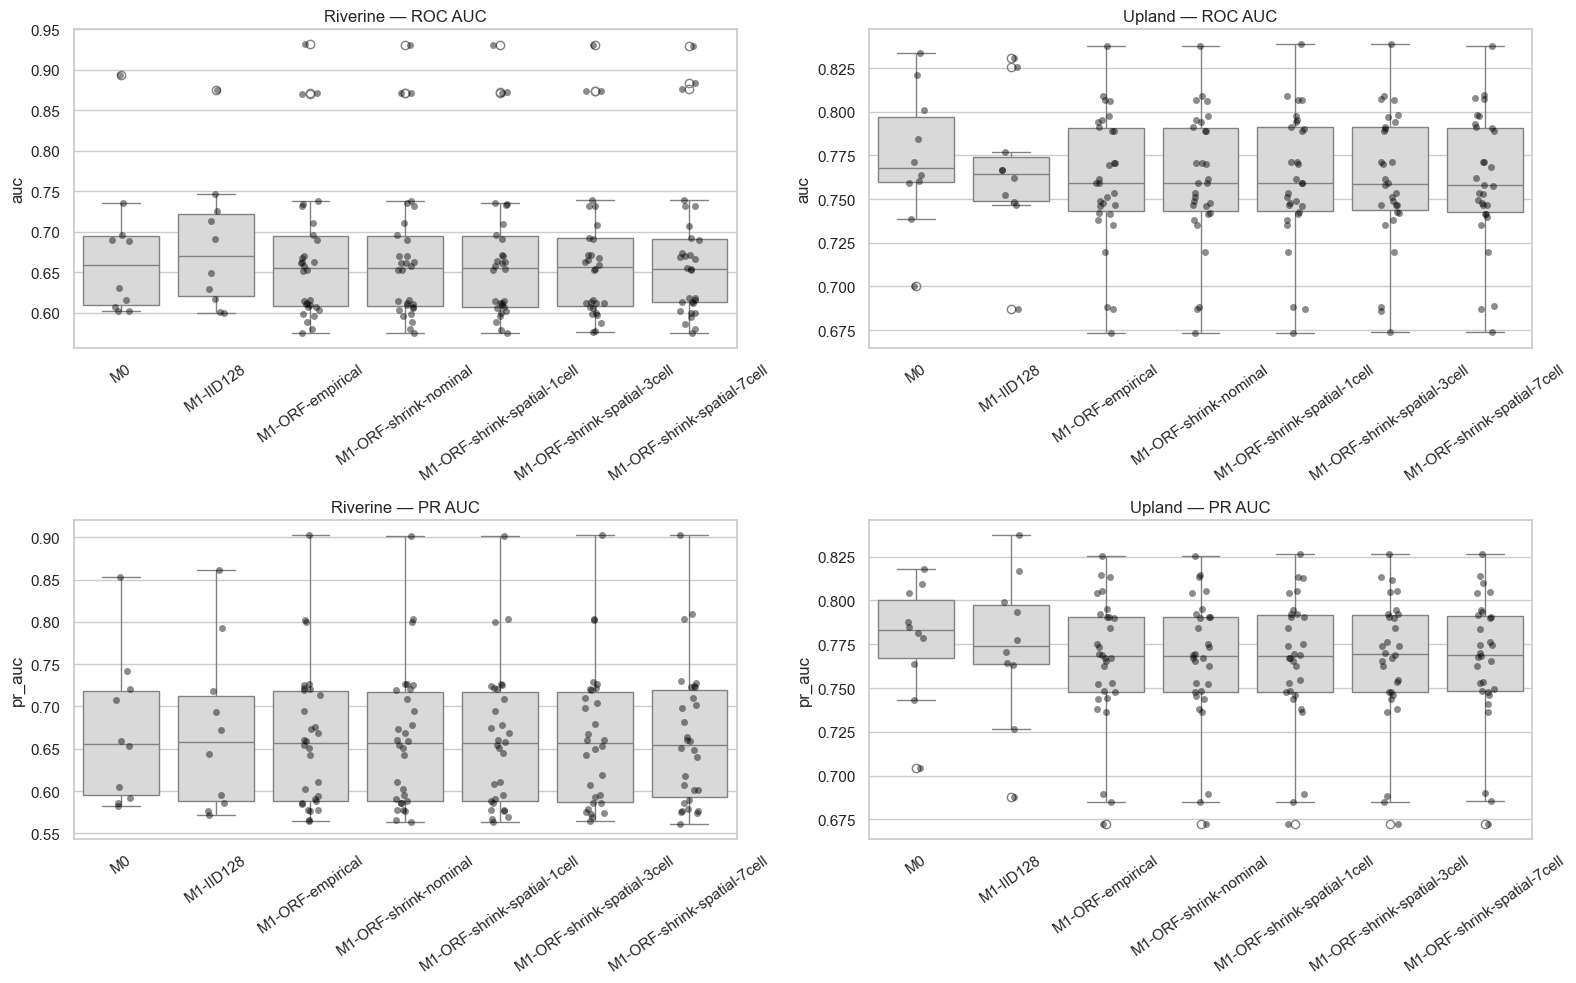

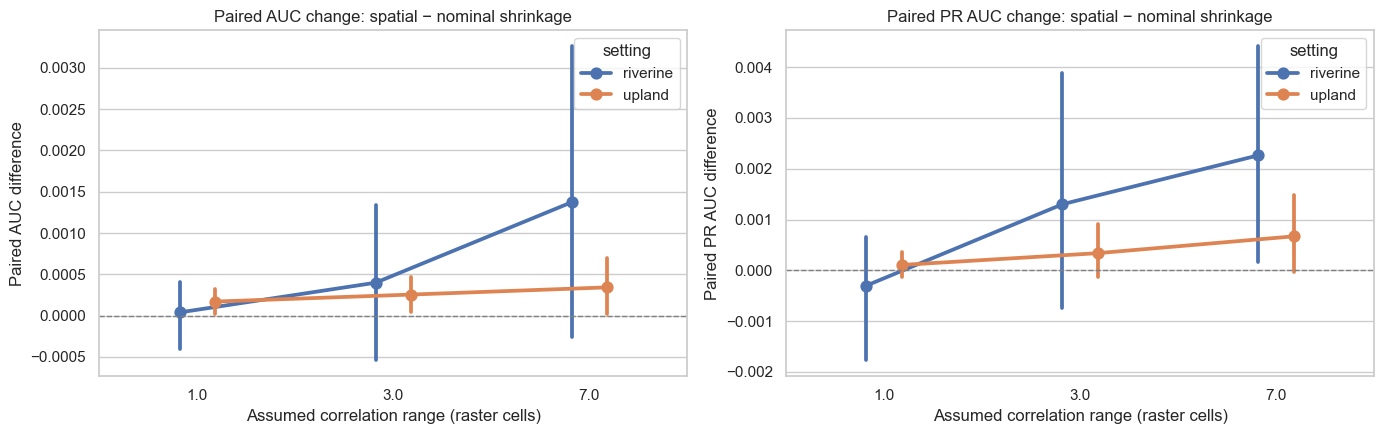

In [29]:
if not extension_cv.empty:
    core_for_plot = cv[cv.method.isin(['M0', 'M1'])].copy()
    core_for_plot['display_method'] = core_for_plot.method.replace({'M1': 'M1-IID128'})
    extension_for_plot = extension_cv.copy()
    extension_for_plot['display_method'] = extension_for_plot['method']
    comparison_plot = pd.concat([core_for_plot, extension_for_plot], ignore_index=True, sort=False)
    method_order = [
        'M0', 'M1-IID128', 'M1-ORF-empirical', 'M1-ORF-shrink-nominal',
        *[f'M1-ORF-shrink-spatial-{value:g}cell' for value in SPATIAL_RANGE_CELL_MULTIPLIERS],
    ]
    fig, axes = plt.subplots(2, len(SETTINGS_TO_RUN), figsize=(8 * len(SETTINGS_TO_RUN), 10))
    axes = np.asarray(axes).reshape(2, len(SETTINGS_TO_RUN))
    for column, setting_name in enumerate(SETTINGS_TO_RUN):
        subset = comparison_plot[comparison_plot.setting == setting_name]
        for row, (metric, label) in enumerate([('auc', 'ROC AUC'), ('pr_auc', 'PR AUC')]):
            sns.boxplot(
                data=subset, x='display_method', y=metric, order=method_order,
                color='0.85', ax=axes[row, column],
            )
            sns.stripplot(
                data=subset, x='display_method', y=metric, order=method_order,
                color='black', alpha=0.45, ax=axes[row, column],
            )
            axes[row, column].set_title(f'{setting_name.title()} — {label}')
            axes[row, column].set_xlabel('')
            axes[row, column].tick_params(axis='x', rotation=35)
    plt.tight_layout()

    pairing_keys = ['setting', 'seed', 'repeat', 'fold']
    nominal = extension_cv[extension_cv.method == 'M1-ORF-shrink-nominal'][
        [*pairing_keys, 'auc', 'pr_auc', 'boyce', 'top_5_percent_lift']
    ].rename(columns={
        metric: f'{metric}_nominal'
        for metric in ['auc', 'pr_auc', 'boyce', 'top_5_percent_lift']
    })
    spatial_rows = extension_cv[extension_cv.method.str.contains('shrink-spatial')].copy()
    paired_extension = spatial_rows.merge(nominal, on=pairing_keys, validate='many_to_one')
    for metric in ['auc', 'pr_auc', 'boyce', 'top_5_percent_lift']:
        paired_extension[f'{metric}_delta_vs_nominal'] = (
            paired_extension[metric] - paired_extension[f'{metric}_nominal']
        )
    paired_extension_summary = (
        paired_extension.groupby(['setting', 'range_cells'])
        .agg(
            n_pairs=('auc_delta_vs_nominal', 'count'),
            auc_delta=('auc_delta_vs_nominal', 'mean'),
            auc_delta_se=('auc_delta_vs_nominal', lambda x: x.std() / np.sqrt(x.count())),
            pr_auc_delta=('pr_auc_delta_vs_nominal', 'mean'),
            boyce_delta=('boyce_delta_vs_nominal', 'mean'),
            top5_lift_delta=('top_5_percent_lift_delta_vs_nominal', 'mean'),
        )
        .round(4)
    )
    display(paired_extension_summary)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, (metric, label) in zip(
        axes, [('auc_delta_vs_nominal', 'AUC'), ('pr_auc_delta_vs_nominal', 'PR AUC')]
    ):
        sns.pointplot(
            data=paired_extension, x='range_cells', y=metric, hue='setting',
            errorbar=('ci', 95),
            dodge=0.18 if paired_extension.setting.nunique() > 1 else False,
            ax=ax,
        )
        ax.axhline(0, color='grey', linestyle='--', linewidth=1)
        ax.set_title(f'Paired {label} change: spatial − nominal shrinkage')
        ax.set_xlabel('Assumed correlation range (raster cells)')
        ax.set_ylabel(f'Paired {label} difference')
    plt.tight_layout()

### 8.1 Seed-ensemble map comparison

The maps below fit the same dedicated training partition used in Section 4. They average predictions over the configured ORF seeds and compare empirical ORF, nominal shrinkage, and spatial shrinkage at the selected middle range. The difference map and seed-standard-deviation map are diagnostic: coherent changes are more credible than isolated speckling, edge artifacts, or regions dominated by feature-map randomness.

In [30]:
def extension_map_specifications(setting_name):
    coordinate_range = extension_range_units[setting_name][EXTENSION_MAP_RANGE_CELLS]
    return {
        'ORF empirical': ModelSpec.m1(config['rff_features'], rff_scheme='orthogonal'),
        'ORF nominal shrinkage': ModelSpec.m1(
            config['rff_features'], rff_scheme='orthogonal',
            embedding_estimator='shrinkage',
        ),
        f'ORF spatial shrinkage ({EXTENSION_MAP_RANGE_CELLS:g} cells)': ModelSpec.m1(
            config['rff_features'], rff_scheme='orthogonal',
            embedding_estimator='shrinkage', shrinkage_effective_size='spatial',
            shrinkage_spatial_range=coordinate_range,
        ),
    }

def run_extension_map(setting_name, map_dataset, centers):
    scores = centers.copy()
    train = partition_data[setting_name]['train']
    for method, spec in extension_map_specifications(setting_name).items():
        seed_columns = []
        for seed in EXTENSION_RFF_SEEDS:
            model = DistributionClassifier(
                spec, lambda_reg=config['lambda_reg'], seed=seed, round_exact_kernel=True,
            ).fit(train)
            column = f'{method} — seed {seed}'
            started = time.perf_counter()
            scores[column] = predict_map_batched(
                model, map_dataset, EXTENSION_MAP_BATCH_SIZE,
                description=f'{setting_name} {method} seed {seed}',
            )
            seed_columns.append(column)
            print(f'{setting_name} {column}: {time.perf_counter() - started:.2f}s')
        scores[f'{method} mean'] = scores[seed_columns].mean(axis=1)
        scores[f'{method} seed sd'] = scores[seed_columns].std(axis=1, ddof=0)
    spatial_name = f'ORF spatial shrinkage ({EXTENSION_MAP_RANGE_CELLS:g} cells)'
    scores['spatial_minus_nominal'] = (
        scores[f'{spatial_name} mean'] - scores['ORF nominal shrinkage mean']
    )
    return scores

extension_map_scores = {}
if RUN_EXTENSION_MAPS:
    map_inputs = {
        MAP_SETTING: (map_bags, map_centers),
        UPLAND_MAP_SETTING: (upland_map_bags, upland_map_centers),
    }
    for setting_name in SETTINGS_TO_RUN:
        if setting_name not in map_inputs:
            warnings.warn(f'No focal map bags are available for {setting_name}.')
            continue
        extension_map_scores[setting_name] = run_extension_map(
            setting_name, *map_inputs[setting_name],
        )
else:
    print('Extension map fitting is disabled.')

riverine ORF empirical seed 42: 100%|██████████| 4/4 [00:01<00:00,  2.09it/s]


riverine ORF empirical — seed 42: 1.92s


riverine ORF empirical seed 314: 100%|██████████| 4/4 [00:00<00:00,  4.36it/s]


riverine ORF empirical — seed 314: 0.92s


riverine ORF empirical seed 2718: 100%|██████████| 4/4 [00:00<00:00,  4.28it/s]


...

upland ORF spatial shrinkage (3 cells) — seed 42: 12.66s


upland ORF spatial shrinkage (3 cells) seed 314: 100%|██████████| 23/23 [00:12<00:00,  1.78it/s]


upland ORF spatial shrinkage (3 cells) — seed 314: 12.89s


upland ORF spatial shrinkage (3 cells) seed 2718: 100%|██████████| 23/23 [00:12<00:00,  1.80it/s]

upland ORF spatial shrinkage (3 cells) — seed 2718: 12.76s


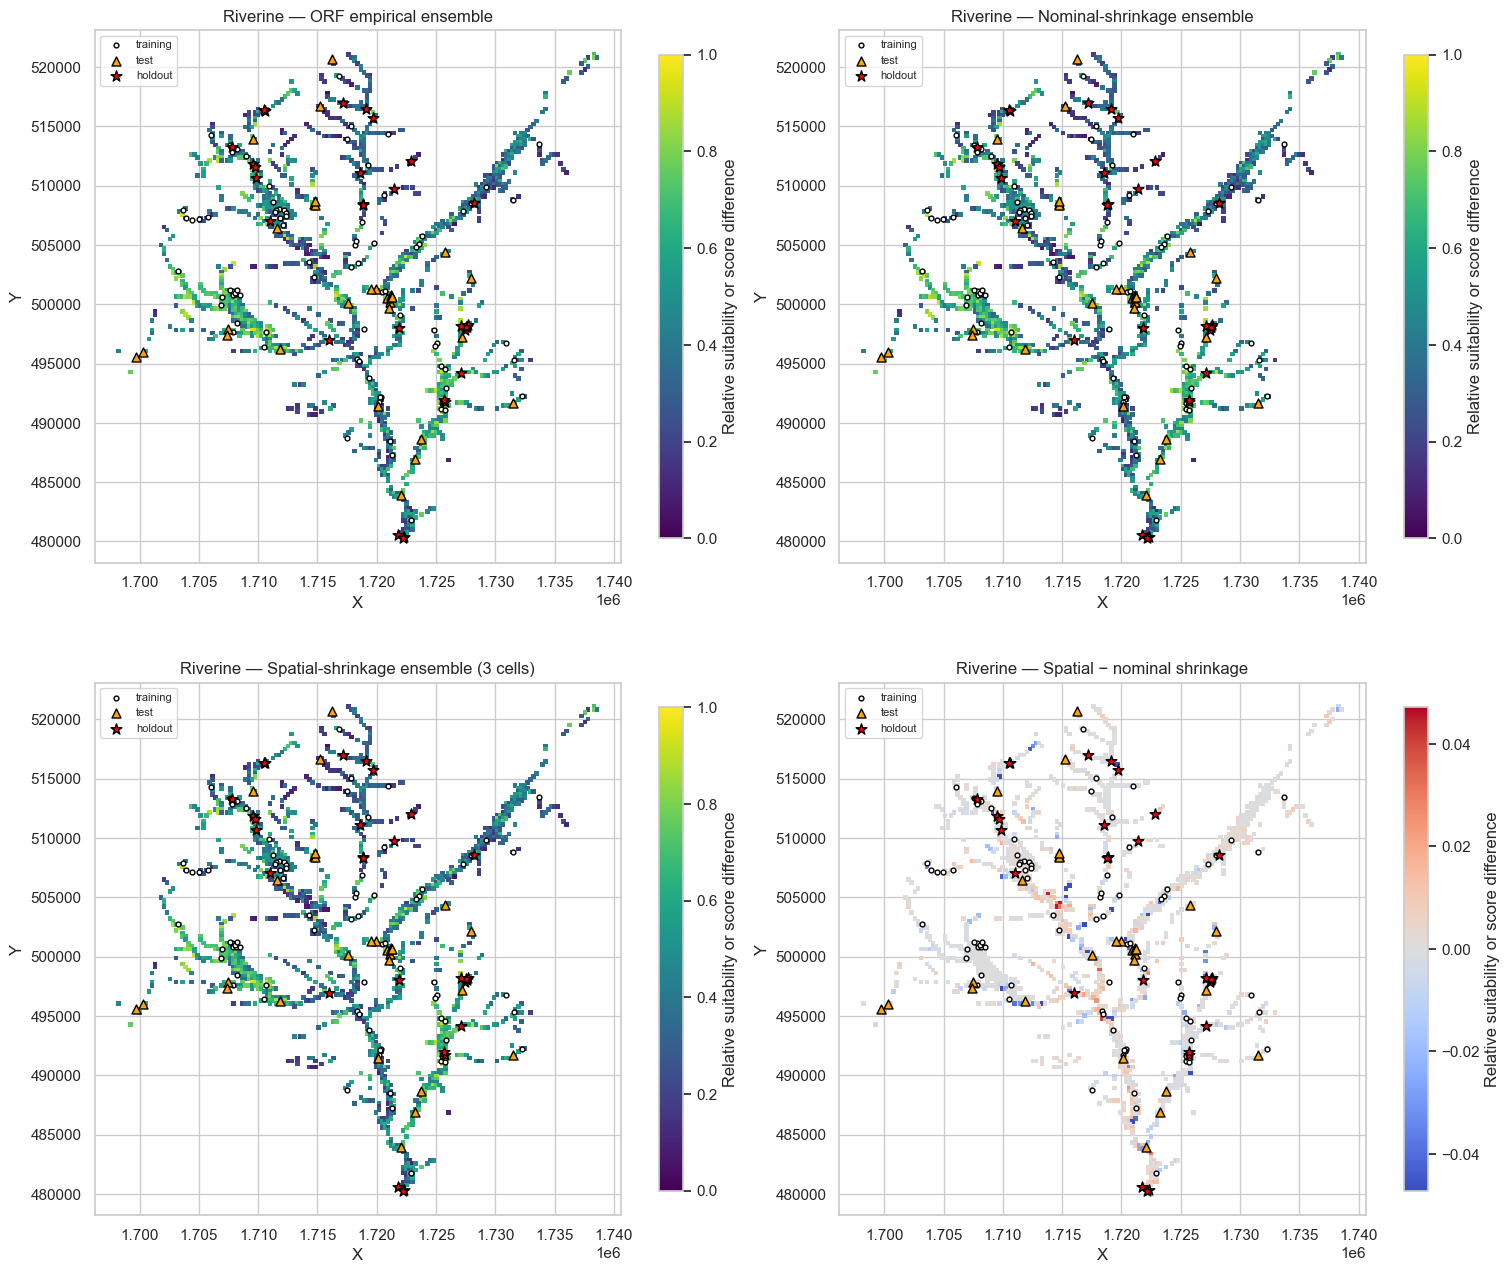

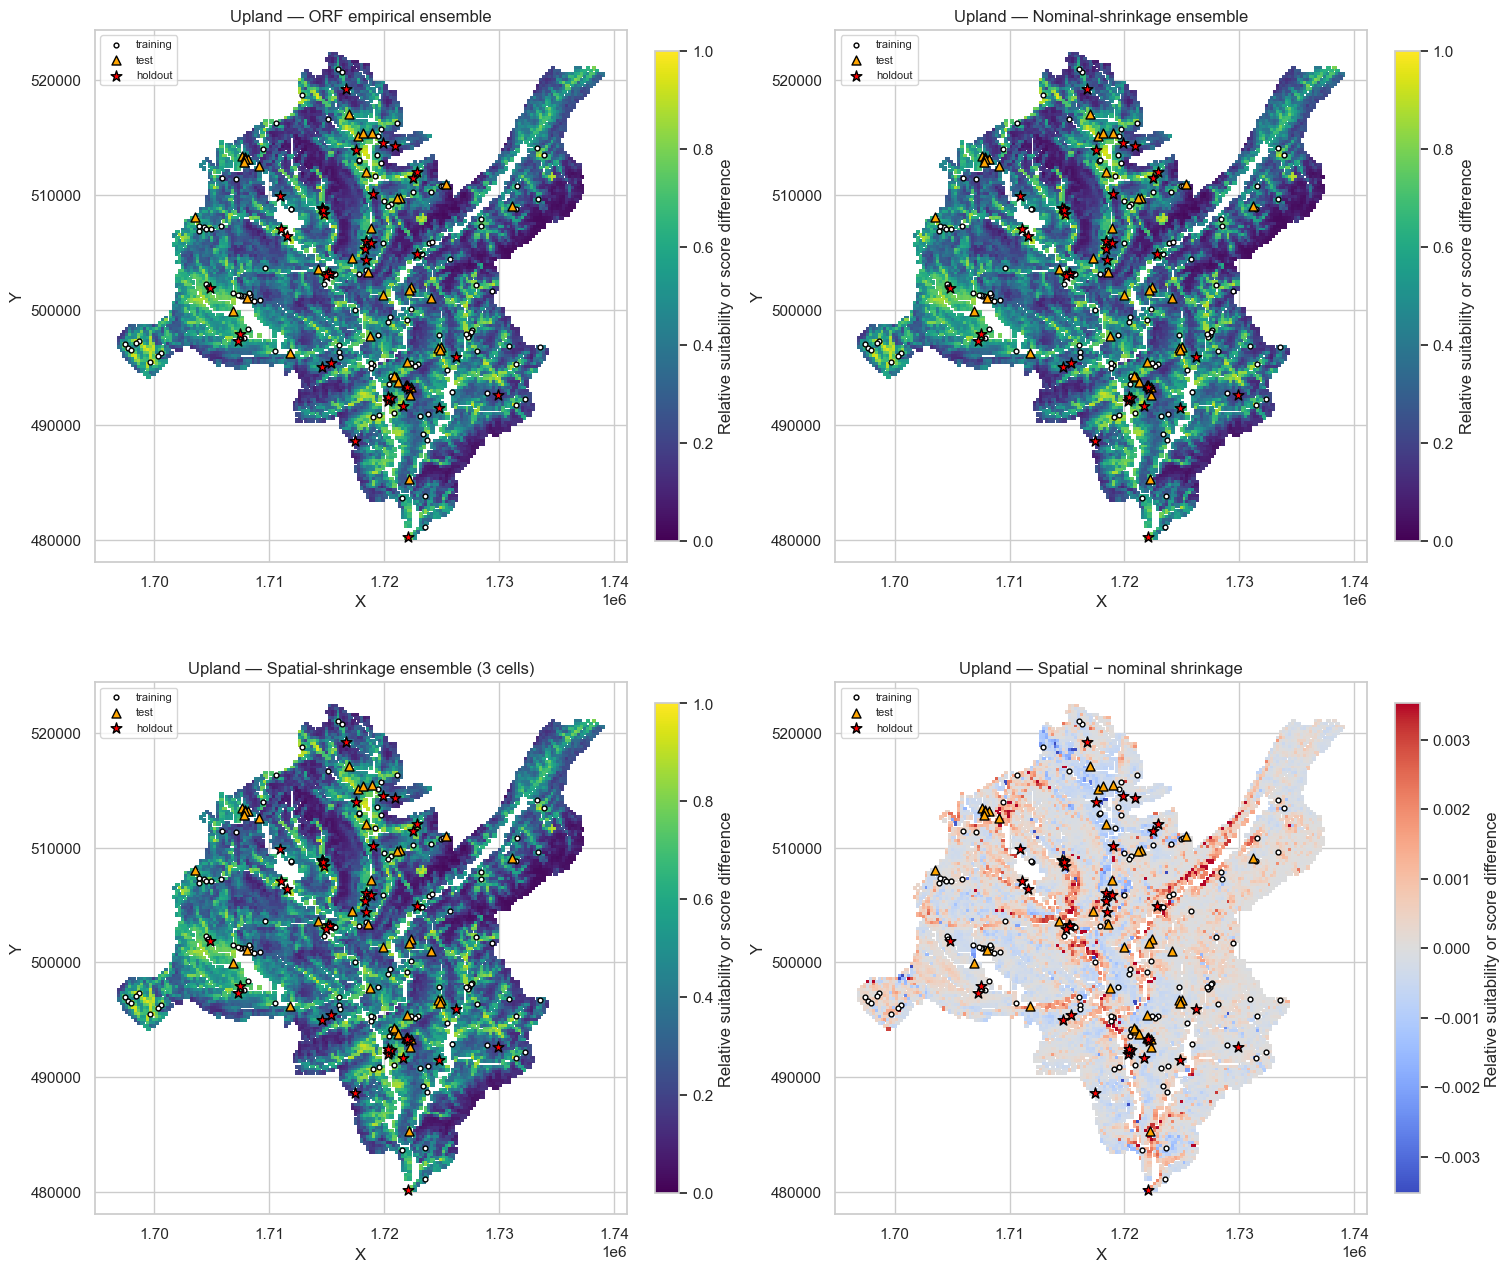

,setting,method,median_seed_sd,p95_seed_sd,maximum_seed_sd
0,riverine,ORF empirical,0.02322,0.07519,0.19225
1,riverine,ORF nominal shrinkage,0.02323,0.07485,0.19170
2,riverine,ORF spatial shrinkage (3 cells),0.02280,0.06869,0.18531
3,upland,ORF empirical,0.02796,0.08824,0.24117
4,upland,ORF nominal shrinkage,0.02794,0.08821,0.24116
5,upland,ORF spatial shrinkage (3 cells),0.02785,0.08767,0.24120


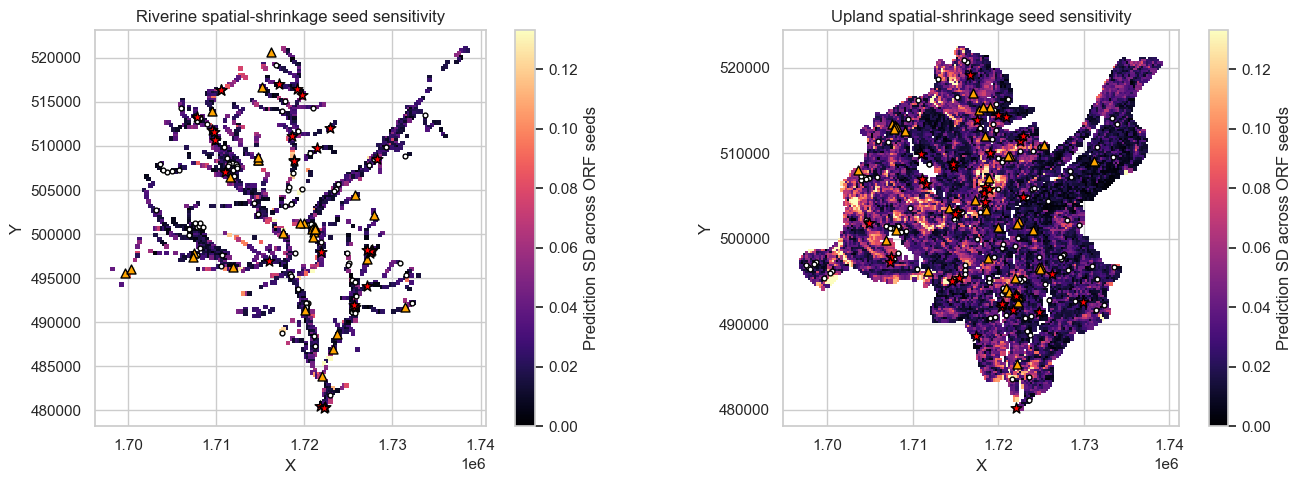

In [31]:
def add_validation_sites(ax, setting_name):
    training = site_centroids(partition_data[setting_name]['train'])
    test = site_centroids(partition_data[setting_name]['test'])
    holdout = site_centroids(partition_data[setting_name]['holdout'])
    ax.scatter(training.x, training.y, s=12, c='white', edgecolors='black', label='training')
    ax.scatter(test.x, test.y, s=42, marker='^', c='orange', edgecolors='black', label='test')
    ax.scatter(holdout.x, holdout.y, s=66, marker='*', c='red', edgecolors='black', label='holdout')

map_stability_rows = []
for setting_name, scores in extension_map_scores.items():
    spatial_name = f'ORF spatial shrinkage ({EXTENSION_MAP_RANGE_CELLS:g} cells)'
    panels = [
        ('ORF empirical mean', 'ORF empirical ensemble', 'viridis', 0, 1),
        ('ORF nominal shrinkage mean', 'Nominal-shrinkage ensemble', 'viridis', 0, 1),
        (f'{spatial_name} mean', f'Spatial-shrinkage ensemble ({EXTENSION_MAP_RANGE_CELLS:g} cells)', 'viridis', 0, 1),
    ]
    difference_limit = max(float(np.nanpercentile(np.abs(scores.spatial_minus_nominal), 99)), 1e-6)
    panels.append((
        'spatial_minus_nominal', 'Spatial − nominal shrinkage',
        'coolwarm', -difference_limit, difference_limit,
    ))
    fig, axes = plt.subplots(2, 2, figsize=(15, 13), constrained_layout=True)
    for ax, (column, title, cmap, vmin, vmax) in zip(axes.ravel(), panels):
        image = ax.scatter(
            scores.x, scores.y, c=scores[column], s=11, marker='s',
            cmap=cmap, vmin=vmin, vmax=vmax, linewidths=0, rasterized=True,
        )
        add_validation_sites(ax, setting_name)
        ax.set_title(f'{setting_name.title()} — {title}')
        ax.set_aspect('equal')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.legend(loc='best', fontsize=8)
        fig.colorbar(image, ax=ax, shrink=0.8, label='Relative suitability or score difference')
    plt.show()

    for method in extension_map_specifications(setting_name):
        seed_sd = scores[f'{method} seed sd']
        map_stability_rows.append({
            'setting': setting_name, 'method': method,
            'median_seed_sd': float(seed_sd.median()),
            'p95_seed_sd': float(seed_sd.quantile(0.95)),
            'maximum_seed_sd': float(seed_sd.max()),
        })

if map_stability_rows:
    map_stability = pd.DataFrame(map_stability_rows)
    display(map_stability.round(5))
    fig, axes = plt.subplots(1, len(extension_map_scores), figsize=(7 * len(extension_map_scores), 5))
    axes = np.atleast_1d(axes)
    spatial_name = f'ORF spatial shrinkage ({EXTENSION_MAP_RANGE_CELLS:g} cells)'
    global_limit = max(
        float(scores[f'{spatial_name} seed sd'].quantile(0.99))
        for scores in extension_map_scores.values()
    )
    for ax, (setting_name, scores) in zip(axes, extension_map_scores.items()):
        image = ax.scatter(
            scores.x, scores.y, c=scores[f'{spatial_name} seed sd'],
            s=11, marker='s', cmap='magma', vmin=0, vmax=max(global_limit, 1e-6),
            linewidths=0, rasterized=True,
        )
        add_validation_sites(ax, setting_name)
        ax.set_title(f'{setting_name.title()} spatial-shrinkage seed sensitivity')
        ax.set_aspect('equal')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        fig.colorbar(image, ax=ax, label='Prediction SD across ORF seeds')
    plt.tight_layout()

## Reading the results

1. Use the repeated spatial-fold tables and paired differences for method comparison; do not rank methods from a single displayed holdout.
2. Boyce and lift are the most directly useful presence-background ranking diagnostics. PR AUC depends on the constructed background prevalence.
3. Inspect whether high suitability forms coherent environmental/spatial patterns and whether test and holdout sites fall within those patterns.
4. Map stride changes display resolution, not model fitting. A denser map is computationally expensive, especially for exact M0.
5. Compare LR/RF to M0–M3 on the same spatial folds. RF matching a distribution method means nonlinear feature means are a competitive baseline; it does not prove the distributions add no information.
6. A geometry-only AUC above chance is a sampling-design warning. The common focal-window sensitivity is the cleaner comparison because both classes have the same support rule.
7. In Section 8, first inspect how the assumed range changes site and background effective-size distributions. Then compare spatial shrinkage with nominal shrinkage using paired folds and maps; an AUC tie can still accompany a coherent reduction in feature-map noise.
8. Treat large ORF seed standard deviations or speckled seed-sensitivity maps as approximation instability. Increase the feature budget or retain seed ensembles before interpreting local spatial differences.
9. Do not promote spatial shrinkage, remove M3, or promote M2 from Section 6 alone. The correlation range is not estimated here, and additional physio-sheds plus the pooling decision remain necessary for general conclusions.